# Area Detector Background and Edge Sensitivity Analysis

This notebook provides comprehensive analysis of background levels and sensitivity decay at detector edges for Bruker GADDS area detectors.

## Analysis Objectives:
- Quantify background noise levels across the detector surface
- Identify and characterize sensitivity decay at detector edges
- Create background correction maps
- Analyze radial and angular variations in detector response
- Generate visualizations for quality assessment

## Key Features:
- Radial distance analysis from detector center
- Edge sensitivity quantification
- Background statistical analysis
- 2D background mapping
- Correction factor generation

In [15]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from matplotlib.patches import Circle, Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.ndimage as ndimage
from scipy import stats
from scipy.optimize import curve_fit
from scipy.interpolate import interp2d, griddata
import os
import warnings
from gadds import AreaDetectorImage

# Set up matplotlib for high-quality plots
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
warnings.filterwarnings('ignore', category=RuntimeWarning)

✓ Successfully loaded: test\20250709_S_MeO_B01_000.gfrm
  Image shape: (2048, 2048)
  Data type: uint16
  Detector center: (1003.7000122, 1022.0999756)
  Pixel density: (147.0628052, 147.0628052) pixels/cm

=== Initial Data Analysis ===
Data range: 0 - 1085
Mean: 1.1
Pixels > 0: 2,141,353 (51.1%)
Pixels > 100: 3,483 (0.1%)
Pixels > 500: 557 (0.0%)
Maximum distance with signal: 1007.4 pixels

=== Circular Detector Detection ===
Estimated detector radius: 994.0 pixels
Detector area: 3,104,019 pixels (74.0%)
Signal threshold: 500 counts

=== Circular Detector Detection ===
Estimated detector radius: 994.0 pixels
Detector area: 3,104,019 pixels (74.0%)
Signal threshold: 500 counts


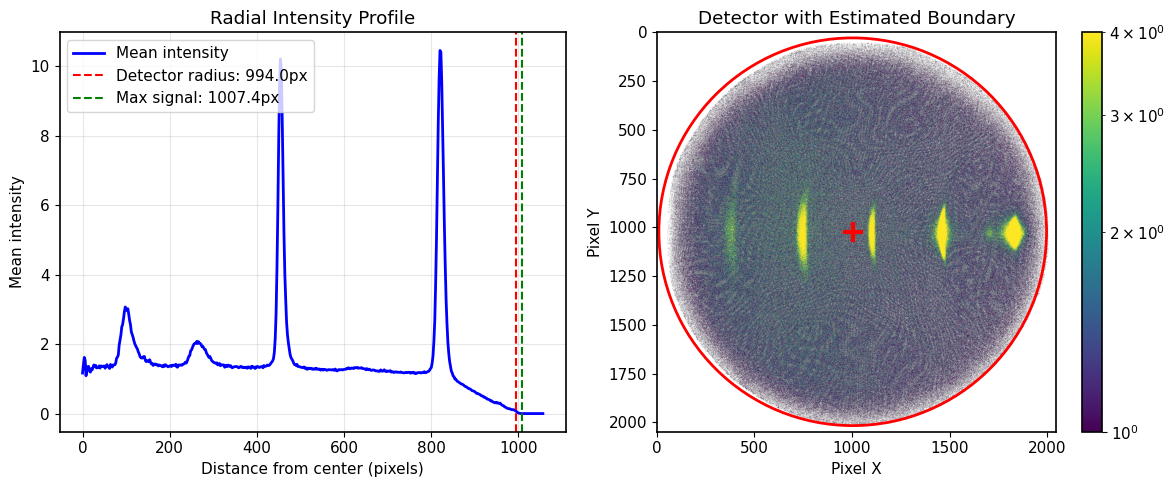


=== Detector Parameters ===
Shape: (2048, 2048)
Center: (1003.7, 1022.1)
Non-zero pixels in detector: 2,139,945 (68.9% of detector area)
Intensity range (non-zero): 1 - 1085
Mean intensity (non-zero): 2.2
Standard deviation: 14.7

Signal pixels (>500): 557 (0.0%)
Background pixels (≤500): 2,139,388 (100.0%)
Signal mean: 705.1 ± 134.7
Background mean: 2.0 ± 9.1


In [16]:
# Load Area Detector Data
# Specify the path to your GFRM file
gfrm_file = r"test\20250709_S_MeO_B01_000.gfrm"

# Load the detector data
try:
    area_detector = AreaDetectorImage(gfrm_file)
    print(f"✓ Successfully loaded: {gfrm_file}")
    print(f"  Image shape: {area_detector.image.data.shape}")
    print(f"  Data type: {area_detector.image.data.dtype}")
    print(f"  Detector center: {area_detector.centerXY}")
    print(f"  Pixel density: {area_detector.densityXY} pixels/cm")
    
    # Get detector data
    detector_data = area_detector.image.data.astype(float)
    
    # Analyze data distribution first
    print(f"\n=== Initial Data Analysis ===")
    print(f"Data range: {np.min(detector_data):.0f} - {np.max(detector_data):.0f}")
    print(f"Mean: {np.mean(detector_data):.1f}")
    print(f"Pixels > 0: {np.sum(detector_data > 0):,} ({np.sum(detector_data > 0)/detector_data.size*100:.1f}%)")
    print(f"Pixels > 100: {np.sum(detector_data > 100):,} ({np.sum(detector_data > 100)/detector_data.size*100:.1f}%)")
    print(f"Pixels > 500: {np.sum(detector_data > 500):,} ({np.sum(detector_data > 500)/detector_data.size*100:.1f}%)")
    
    # Detect circular detector geometry
    center_x, center_y = area_detector.centerXY
    y_coords, x_coords = np.ogrid[:detector_data.shape[0], :detector_data.shape[1]]
    
    # Calculate distance from center
    dist_from_center = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
    
    # Improved detector radius detection
    # Method 1: Look for pixels with any signal (> 0)
    signal_pixels = detector_data > 0
    if np.any(signal_pixels):
        signal_distances = dist_from_center[signal_pixels]
        max_signal_radius = np.max(signal_distances)
        print(f"Maximum distance with signal: {max_signal_radius:.1f} pixels")
    else:
        max_signal_radius = np.min([center_x, center_y, 
                                  detector_data.shape[1] - center_x, 
                                  detector_data.shape[0] - center_y]) * 0.9
    
    # Method 2: Radial profile analysis
    max_radius = int(max_signal_radius + 50)  # Look a bit beyond
    radial_bins = np.arange(0, max_radius, 2)
    radial_intensities = []
    radial_nonzero_counts = []
    
    for r in radial_bins:
        mask = (dist_from_center >= r) & (dist_from_center < r + 2)
        if np.any(mask):
            ring_data = detector_data[mask]
            radial_intensities.append(np.mean(ring_data))
            radial_nonzero_counts.append(np.sum(ring_data > 0))
        else:
            radial_intensities.append(0)
            radial_nonzero_counts.append(0)
    
    radial_intensities = np.array(radial_intensities)
    radial_nonzero_counts = np.array(radial_nonzero_counts)
    
    # Find detector radius where non-zero counts drop significantly
    # Look for the radius where less than 10% of pixels have signal
    max_nonzero = np.max(radial_nonzero_counts)
    threshold_count = max_nonzero * 0.1
    
    detector_radius = max_signal_radius
    for i, count in enumerate(radial_nonzero_counts):
        if count < threshold_count and radial_bins[i] > max_signal_radius * 0.5:
            detector_radius = radial_bins[i]
            break
    
    # Alternative method: use intensity drop
    if detector_radius == max_signal_radius:
        # Find where intensity drops to very low levels
        max_intensity = np.max(radial_intensities)
        intensity_threshold = max_intensity * 0.01  # 1% of max
        
        for i, intensity in enumerate(radial_intensities):
            if intensity < intensity_threshold and radial_bins[i] > max_signal_radius * 0.7:
                detector_radius = radial_bins[i]
                break
    
    # Ensure reasonable radius
    detector_radius = min(detector_radius, max_signal_radius * 1.1)
    detector_radius = max(detector_radius, max_signal_radius * 0.9)
    
    # Use signal threshold (counts > 500 are signals, rest is background)
    signal_threshold = 500
    
    # Create circular detector mask
    detector_mask = dist_from_center <= detector_radius
    
    # Apply detector mask to data (set areas outside detector to NaN for display)
    detector_data_masked = detector_data.copy()
    detector_data_masked[~detector_mask] = np.nan
    
    print(f"\n=== Circular Detector Detection ===")
    print(f"Estimated detector radius: {detector_radius:.1f} pixels")
    print(f"Detector area: {np.sum(detector_mask):,} pixels ({np.sum(detector_mask)/detector_mask.size*100:.1f}%)")
    print(f"Signal threshold: {signal_threshold} counts")
    
    # Quick validation plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Show radial profile
    ax1.plot(radial_bins, radial_intensities, 'b-', linewidth=2, label='Mean intensity')
    ax1.axvline(detector_radius, color='red', linestyle='--', label=f'Detector radius: {detector_radius:.1f}px')
    ax1.axvline(max_signal_radius, color='green', linestyle='--', label=f'Max signal: {max_signal_radius:.1f}px')
    ax1.set_xlabel('Distance from center (pixels)')
    ax1.set_ylabel('Mean intensity')
    ax1.set_title('Radial Intensity Profile')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Show detector with boundary
    im = ax2.imshow(detector_data, cmap='viridis', norm=colors.LogNorm(vmin=1, vmax=np.percentile(detector_data, 99)))
    circle = Circle((center_x, center_y), detector_radius, fill=False, color='red', linewidth=2)
    ax2.add_patch(circle)
    ax2.plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=3)
    ax2.set_title('Detector with Estimated Boundary')
    ax2.set_xlabel('Pixel X')
    ax2.set_ylabel('Pixel Y')
    plt.colorbar(im, ax=ax2)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Error loading file: {e}")
    print("Please check that the GFRM file exists and is accessible.")
    raise

# Extract key parameters
detector_center = area_detector.centerXY
detector_shape = detector_data.shape
print(f"\n=== Detector Parameters ===")
print(f"Shape: {detector_shape}")
print(f"Center: ({detector_center[0]:.1f}, {detector_center[1]:.1f})")

# Analyze intensity distribution within detector area
detector_pixels = detector_data[detector_mask]
detector_pixels_clean = detector_pixels[detector_pixels > 0]  # Only consider non-zero pixels

if len(detector_pixels_clean) > 0:
    print(f"Non-zero pixels in detector: {len(detector_pixels_clean):,} ({len(detector_pixels_clean)/np.sum(detector_mask)*100:.1f}% of detector area)")
    print(f"Intensity range (non-zero): {np.min(detector_pixels_clean):.0f} - {np.max(detector_pixels_clean):.0f}")
    print(f"Mean intensity (non-zero): {np.mean(detector_pixels_clean):.1f}")
    print(f"Standard deviation: {np.std(detector_pixels_clean):.1f}")
    
    # Separate signal and background
    signal_pixels = detector_pixels_clean[detector_pixels_clean > signal_threshold]
    background_pixels = detector_pixels_clean[detector_pixels_clean <= signal_threshold]
    
    print(f"\nSignal pixels (>{signal_threshold}): {len(signal_pixels):,} ({len(signal_pixels)/len(detector_pixels_clean)*100:.1f}%)")
    print(f"Background pixels (≤{signal_threshold}): {len(background_pixels):,} ({len(background_pixels)/len(detector_pixels_clean)*100:.1f}%)")
    
    if len(signal_pixels) > 0:
        print(f"Signal mean: {np.mean(signal_pixels):.1f} ± {np.std(signal_pixels):.1f}")
    if len(background_pixels) > 0:
        print(f"Background mean: {np.mean(background_pixels):.1f} ± {np.std(background_pixels):.1f}")
else:
    print("No valid detector data found!")

# Store detector geometry information
detector_geometry = {
    'center': detector_center,
    'radius': detector_radius,
    'mask': detector_mask,
    'distance_from_center': dist_from_center,
    'signal_threshold': signal_threshold,
    'background_threshold': signal_threshold * 0.1
}

=== Background Statistics Analysis ===

Detector area: 3,104,019 pixels
Background pixels (≤500): 3,103,462 (100.0%)
Signal pixels (>500): 557 (0.0%)
Non-zero background pixels: 2,139,388

--- Background Statistics (non-zero pixels) ---
Mean: 1.99 ± 9.10
Median: 1.00
Range: 1 - 498
Percentiles: {1: '1.0', 5: '1.0', 10: '1.0', 25: '1.0', 75: '2.0', 90: '3.0', 95: '3.0', 99: '6.0'}

Background noise level (1σ): 9.10
3σ threshold: 29.3
5σ threshold: 47.5

--- Signal Statistics ---
Signal mean: 705.1 ± 134.7
Signal range: 501 - 1085


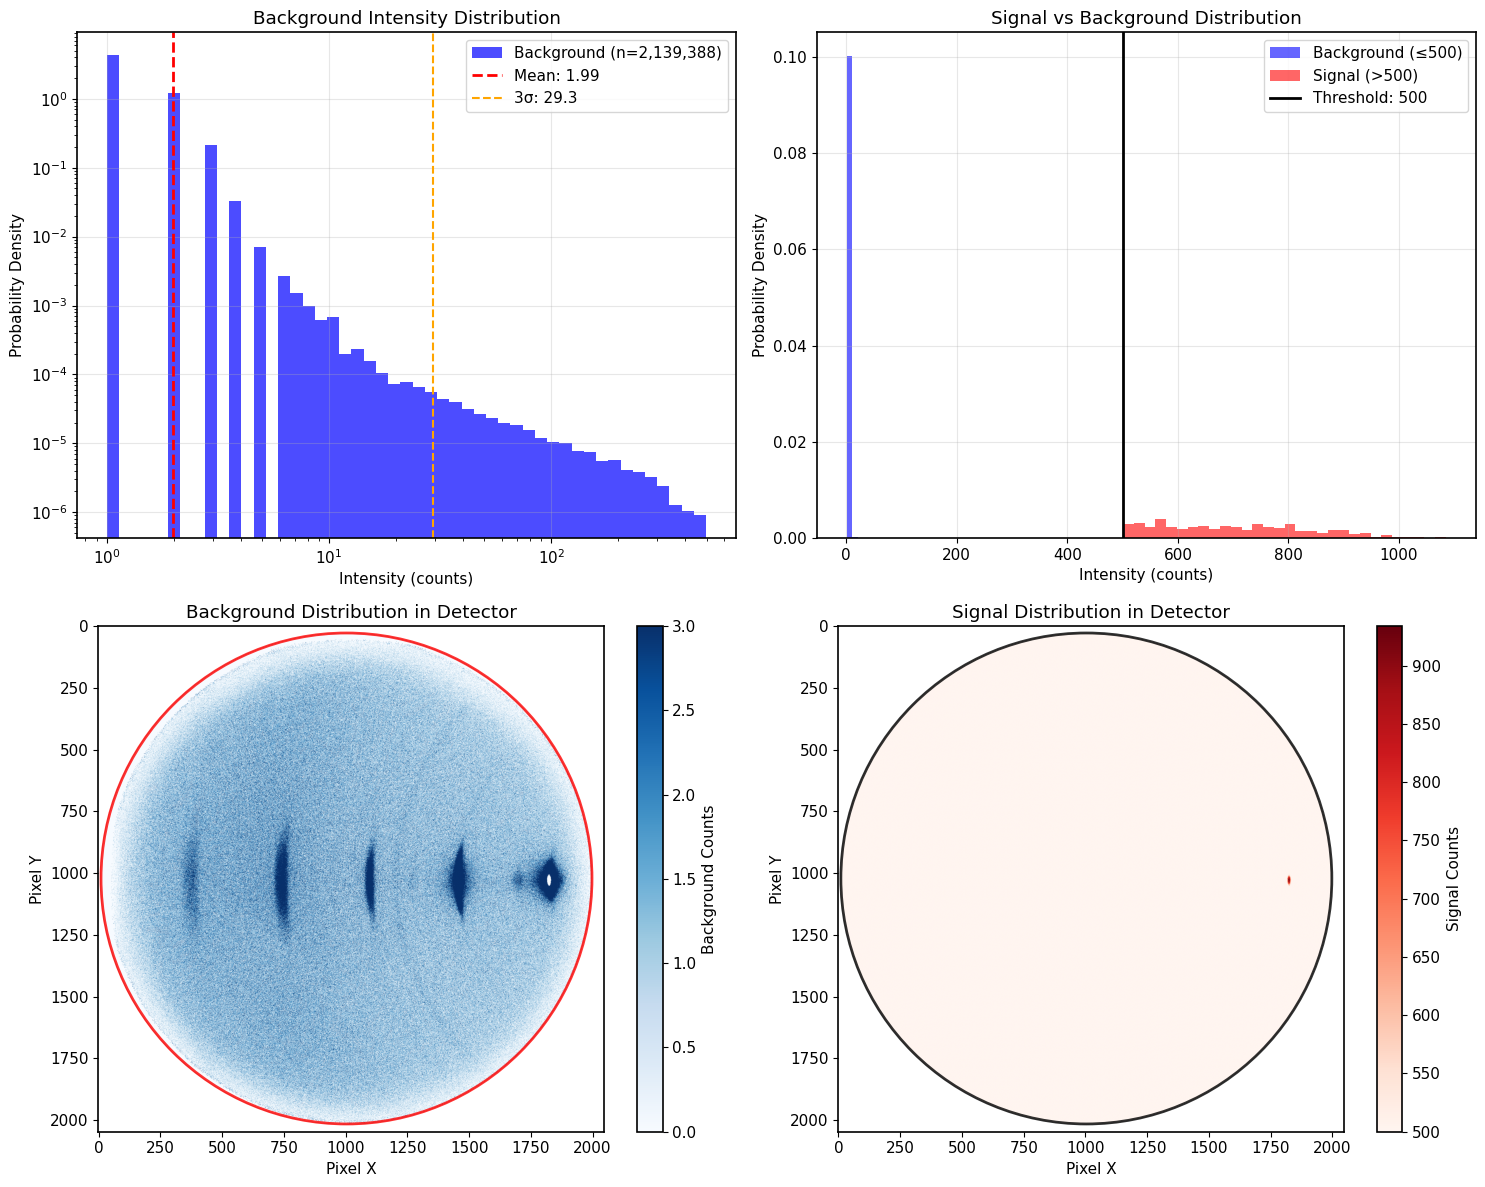


✓ Background analysis complete. Found 2,139,388 background pixels with mean 1.99 ± 9.10


In [17]:
# Background Statistics Analysis for Circular Detector
print("=== Background Statistics Analysis ===\n")

# Use the circular detector mask and signal threshold from the detector geometry
detector_mask = detector_geometry['mask']
signal_threshold = detector_geometry['signal_threshold']
background_threshold = detector_geometry['background_threshold']

# Extract background pixels (within detector area, ≤ signal threshold)
background_mask = detector_mask & (detector_data <= signal_threshold)
background_pixels = detector_data[background_mask]

# Extract signal pixels (within detector area, > signal threshold)
signal_mask = detector_mask & (detector_data > signal_threshold)
signal_pixels = detector_data[signal_mask]

# Remove zero values for meaningful statistics
background_nonzero = background_pixels[background_pixels > 0]
signal_nonzero = signal_pixels[signal_pixels > 0] if len(signal_pixels) > 0 else np.array([])

print(f"Detector area: {np.sum(detector_mask):,} pixels")
print(f"Background pixels (≤{signal_threshold}): {len(background_pixels):,} ({len(background_pixels)/np.sum(detector_mask)*100:.1f}%)")
print(f"Signal pixels (>{signal_threshold}): {len(signal_pixels):,} ({len(signal_pixels)/np.sum(detector_mask)*100:.1f}%)")
print(f"Non-zero background pixels: {len(background_nonzero):,}")

if len(background_nonzero) > 0:
    # Background statistics
    bg_mean = np.mean(background_nonzero)
    bg_std = np.std(background_nonzero)
    bg_median = np.median(background_nonzero)
    bg_min = np.min(background_nonzero)
    bg_max = np.max(background_nonzero)
    
    print(f"\n--- Background Statistics (non-zero pixels) ---")
    print(f"Mean: {bg_mean:.2f} ± {bg_std:.2f}")
    print(f"Median: {bg_median:.2f}")
    print(f"Range: {bg_min:.0f} - {bg_max:.0f}")
    
    # Background percentiles
    percentiles = [1, 5, 10, 25, 75, 90, 95, 99]
    bg_percentiles = np.percentile(background_nonzero, percentiles)
    print(f"Percentiles: {dict(zip(percentiles, [f'{p:.1f}' for p in bg_percentiles]))}")
    
    # Estimate background noise level
    bg_noise_level = bg_std
    bg_threshold_3sigma = bg_mean + 3 * bg_std
    bg_threshold_5sigma = bg_mean + 5 * bg_std
    
    print(f"\nBackground noise level (1σ): {bg_noise_level:.2f}")
    print(f"3σ threshold: {bg_threshold_3sigma:.1f}")
    print(f"5σ threshold: {bg_threshold_5sigma:.1f}")
else:
    print("No non-zero background pixels found!")

if len(signal_nonzero) > 0:
    print(f"\n--- Signal Statistics ---")
    print(f"Signal mean: {np.mean(signal_nonzero):.1f} ± {np.std(signal_nonzero):.1f}")
    print(f"Signal range: {np.min(signal_nonzero):.0f} - {np.max(signal_nonzero):.0f}")

# Create visualization of background distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Background histogram
if len(background_nonzero) > 0:
    # Use log scale for histogram to see low-count bins
    hist_bins = np.logspace(0, np.log10(max(np.max(background_nonzero), 100)), 50)
    ax1.hist(background_nonzero, bins=hist_bins, alpha=0.7, color='blue', 
             density=True, label=f'Background (n={len(background_nonzero):,})')
    ax1.axvline(bg_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {bg_mean:.2f}')
    ax1.axvline(bg_threshold_3sigma, color='orange', linestyle='--', label=f'3σ: {bg_threshold_3sigma:.1f}')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Intensity (counts)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Background Intensity Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# 2. Signal vs background comparison
if len(signal_nonzero) > 0 and len(background_nonzero) > 0:
    ax2.hist(background_nonzero, bins=50, alpha=0.6, color='blue', 
             density=True, label=f'Background (≤{signal_threshold})')
    ax2.hist(signal_nonzero, bins=30, alpha=0.6, color='red', 
             density=True, label=f'Signal (>{signal_threshold})')
    ax2.axvline(signal_threshold, color='black', linestyle='-', linewidth=2, 
                label=f'Threshold: {signal_threshold}')
    ax2.set_xlabel('Intensity (counts)')
    ax2.set_ylabel('Probability Density')
    ax2.set_title('Signal vs Background Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# 3. Detector image with background/signal overlay
background_overlay = np.zeros_like(detector_data)
signal_overlay = np.zeros_like(detector_data)

background_overlay[background_mask] = detector_data[background_mask]
signal_overlay[signal_mask] = detector_data[signal_mask]

# Set areas outside detector to NaN for better visualization
background_overlay[~detector_mask] = np.nan
signal_overlay[~detector_mask] = np.nan

im3 = ax3.imshow(background_overlay, cmap='Blues', vmin=0, vmax=np.percentile(background_nonzero, 95))
circle3 = Circle(detector_geometry['center'], detector_geometry['radius'], 
                fill=False, color='red', linewidth=2, alpha=0.8)
ax3.add_patch(circle3)
ax3.set_title('Background Distribution in Detector')
ax3.set_xlabel('Pixel X')
ax3.set_ylabel('Pixel Y')
plt.colorbar(im3, ax=ax3, label='Background Counts')

# 4. Signal distribution
if len(signal_nonzero) > 0:
    im4 = ax4.imshow(signal_overlay, cmap='Reds', vmin=signal_threshold, 
                     vmax=np.percentile(signal_nonzero, 95))
    circle4 = Circle(detector_geometry['center'], detector_geometry['radius'], 
                    fill=False, color='black', linewidth=2, alpha=0.8)
    ax4.add_patch(circle4)
    ax4.set_title('Signal Distribution in Detector')
    ax4.set_xlabel('Pixel X')
    ax4.set_ylabel('Pixel Y')
    plt.colorbar(im4, ax=ax4, label='Signal Counts')
else:
    ax4.text(0.5, 0.5, 'No signal pixels found\n(all counts ≤ 500)', 
             transform=ax4.transAxes, ha='center', va='center', fontsize=14)
    ax4.set_title('Signal Distribution in Detector')

plt.tight_layout()
plt.show()

# Store background statistics for later use
background_stats = {
    'mean': bg_mean if len(background_nonzero) > 0 else 0,
    'std': bg_std if len(background_nonzero) > 0 else 0,
    'median': bg_median if len(background_nonzero) > 0 else 0,
    'noise_level': bg_noise_level if len(background_nonzero) > 0 else 0,
    'threshold_3sigma': bg_threshold_3sigma if len(background_nonzero) > 0 else 0,
    'threshold_5sigma': bg_threshold_5sigma if len(background_nonzero) > 0 else 0,
    'n_background_pixels': len(background_nonzero),
    'n_signal_pixels': len(signal_nonzero)
}

print(f"\n✓ Background analysis complete. Found {len(background_nonzero):,} background pixels with mean {bg_mean:.2f} ± {bg_std:.2f}")

=== Radial Analysis Results ===
Maximum radius from center: 1462.5 pixels
Center position: (1003.7, 1022.1)
Center intensity: 0.7
Edge intensity (avg last 20 pixels): 0.0
Edge/Center ratio: 0.000


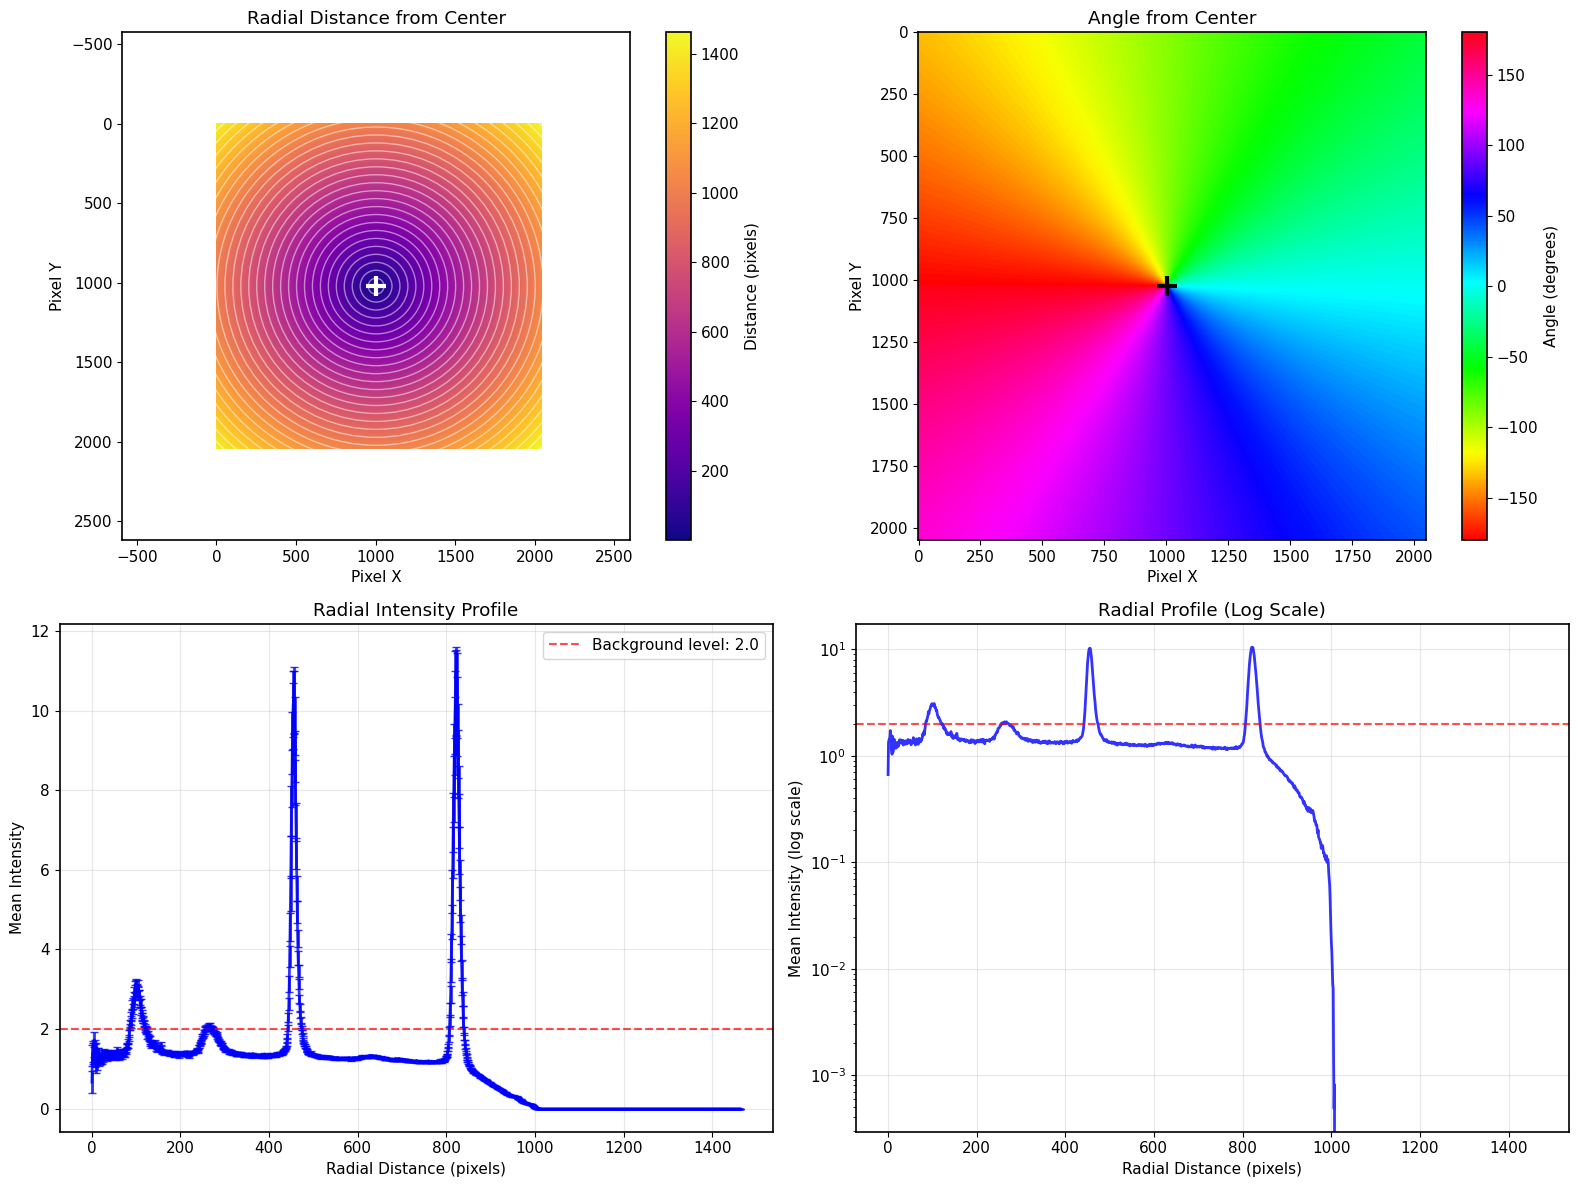


=== Edge Decay Analysis ===
Edge region starts at radius: 1169.0 pixels
Exponential decay fit: I = 1.0 * exp(-1.0000 * r) + 0.0
Decay length (1/e): 1.0 pixels


In [18]:
# Analyze Radial Distance from Center
def create_radial_analysis(data, center_xy):
    """
    Create radial distance maps and profiles from detector center
    """
    center_x, center_y = center_xy
    
    # Create coordinate grids
    y_coords, x_coords = np.ogrid[:data.shape[0], :data.shape[1]]
    
    # Calculate distance from center
    radial_distance = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
    
    # Calculate angle from center (for angular analysis)
    angle_from_center = np.arctan2(y_coords - center_y, x_coords - center_x)
    angle_from_center = np.degrees(angle_from_center)  # Convert to degrees
    
    # Create radial profile by averaging in radial bins
    max_radius = np.max(radial_distance)
    radial_bins = np.arange(0, max_radius + 1, 1)  # 1-pixel bins
    radial_profile = []
    radial_std = []
    radial_count = []
    
    for i in range(len(radial_bins) - 1):
        r_min, r_max = radial_bins[i], radial_bins[i + 1]
        mask = (radial_distance >= r_min) & (radial_distance < r_max)
        
        if np.any(mask):
            pixels_in_ring = data[mask]
            radial_profile.append(np.mean(pixels_in_ring))
            radial_std.append(np.std(pixels_in_ring))
            radial_count.append(len(pixels_in_ring))
        else:
            radial_profile.append(np.nan)
            radial_std.append(np.nan)
            radial_count.append(0)
    
    radial_centers = (radial_bins[:-1] + radial_bins[1:]) / 2
    
    return {
        'radial_distance': radial_distance,
        'angle_from_center': angle_from_center,
        'radial_centers': radial_centers,
        'radial_profile': np.array(radial_profile),
        'radial_std': np.array(radial_std),
        'radial_count': np.array(radial_count),
        'max_radius': max_radius
    }

# Perform radial analysis
radial_data = create_radial_analysis(detector_data, detector_center)

print("=== Radial Analysis Results ===")
print(f"Maximum radius from center: {radial_data['max_radius']:.1f} pixels")
print(f"Center position: ({detector_center[0]:.1f}, {detector_center[1]:.1f})")

# Find intensity variation with radius
valid_radii = ~np.isnan(radial_data['radial_profile'])
if np.any(valid_radii):
    center_intensity = radial_data['radial_profile'][0] if not np.isnan(radial_data['radial_profile'][0]) else np.nanmean(radial_data['radial_profile'][:5])
    edge_intensity = np.nanmean(radial_data['radial_profile'][-20:])  # Average of outermost 20 pixels
    
    print(f"Center intensity: {center_intensity:.1f}")
    print(f"Edge intensity (avg last 20 pixels): {edge_intensity:.1f}")
    print(f"Edge/Center ratio: {edge_intensity/center_intensity:.3f}")

# Visualize radial analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Radial distance map
im1 = axes[0,0].imshow(radial_data['radial_distance'], cmap='plasma')
axes[0,0].set_title('Radial Distance from Center')
axes[0,0].set_xlabel('Pixel X')
axes[0,0].set_ylabel('Pixel Y')
# Add center marker
axes[0,0].plot(detector_center[0], detector_center[1], 'w+', markersize=15, markeredgewidth=3)
# Add radial circles
for radius in np.arange(50, radial_data['max_radius'], 50):
    circle = Circle(detector_center, radius, fill=False, color='white', alpha=0.5, linewidth=1)
    axes[0,0].add_patch(circle)
plt.colorbar(im1, ax=axes[0,0], label='Distance (pixels)')

# Angular map
im2 = axes[0,1].imshow(radial_data['angle_from_center'], cmap='hsv', vmin=-180, vmax=180)
axes[0,1].set_title('Angle from Center')
axes[0,1].set_xlabel('Pixel X')
axes[0,1].set_ylabel('Pixel Y')
axes[0,1].plot(detector_center[0], detector_center[1], 'k+', markersize=15, markeredgewidth=3)
plt.colorbar(im2, ax=axes[0,1], label='Angle (degrees)')

# Radial intensity profile
valid_mask = valid_radii & (radial_data['radial_count'] > 0)
axes[1,0].errorbar(radial_data['radial_centers'][valid_mask], 
                   radial_data['radial_profile'][valid_mask],
                   yerr=radial_data['radial_std'][valid_mask] / np.sqrt(radial_data['radial_count'][valid_mask]),
                   fmt='b-', alpha=0.8, linewidth=2, capsize=3)
axes[1,0].set_xlabel('Radial Distance (pixels)')
axes[1,0].set_ylabel('Mean Intensity')
axes[1,0].set_title('Radial Intensity Profile')
axes[1,0].grid(True, alpha=0.3)

# Add background level reference
bg_level = background_stats['mean']
axes[1,0].axhline(bg_level, color='red', linestyle='--', alpha=0.7, 
                  label=f'Background level: {bg_level:.1f}')
axes[1,0].legend()

# Radial profile on log scale to show decay
axes[1,1].semilogy(radial_data['radial_centers'][valid_mask], 
                   radial_data['radial_profile'][valid_mask],
                   'b-', linewidth=2, alpha=0.8)
axes[1,1].set_xlabel('Radial Distance (pixels)')
axes[1,1].set_ylabel('Mean Intensity (log scale)')
axes[1,1].set_title('Radial Profile (Log Scale)')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axhline(bg_level, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Calculate sensitivity decay metrics
edge_start = int(0.8 * radial_data['max_radius'])  # Define edge region as outer 20%
edge_indices = radial_data['radial_centers'] >= edge_start
if np.any(edge_indices & valid_mask):
    edge_profile = radial_data['radial_profile'][edge_indices & valid_mask]
    edge_radii = radial_data['radial_centers'][edge_indices & valid_mask]
    
    # Fit exponential decay in edge region
    try:
        def exp_decay(r, a, b, c):
            return a * np.exp(-b * r) + c
        
        popt, pcov = curve_fit(exp_decay, edge_radii, edge_profile, 
                              bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
        
        print(f"\n=== Edge Decay Analysis ===")
        print(f"Edge region starts at radius: {edge_start:.1f} pixels")
        print(f"Exponential decay fit: I = {popt[0]:.1f} * exp(-{popt[1]:.4f} * r) + {popt[2]:.1f}")
        print(f"Decay length (1/e): {1/popt[1]:.1f} pixels")
        
    except Exception as e:
        print(f"Could not fit exponential decay: {e}")

=== Circular Detector Border Sensitivity Analysis ===

Detector radius: 994.0 pixels
Edge analysis width: 50 pixels
Analyzing 20 radial regions

--- Border Sensitivity Analysis ---
Center sensitivity: 1.576
Edge sensitivity (within 50px): 0.207
Sensitivity decay at border: 86.8%
Insufficient data points for exponential fit

--- Border Sensitivity Analysis ---
Center sensitivity: 1.576
Edge sensitivity (within 50px): 0.207
Sensitivity decay at border: 86.8%
Insufficient data points for exponential fit


C:\Users\yrliu98\AppData\Local\Temp\ipykernel_54416\74241636.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


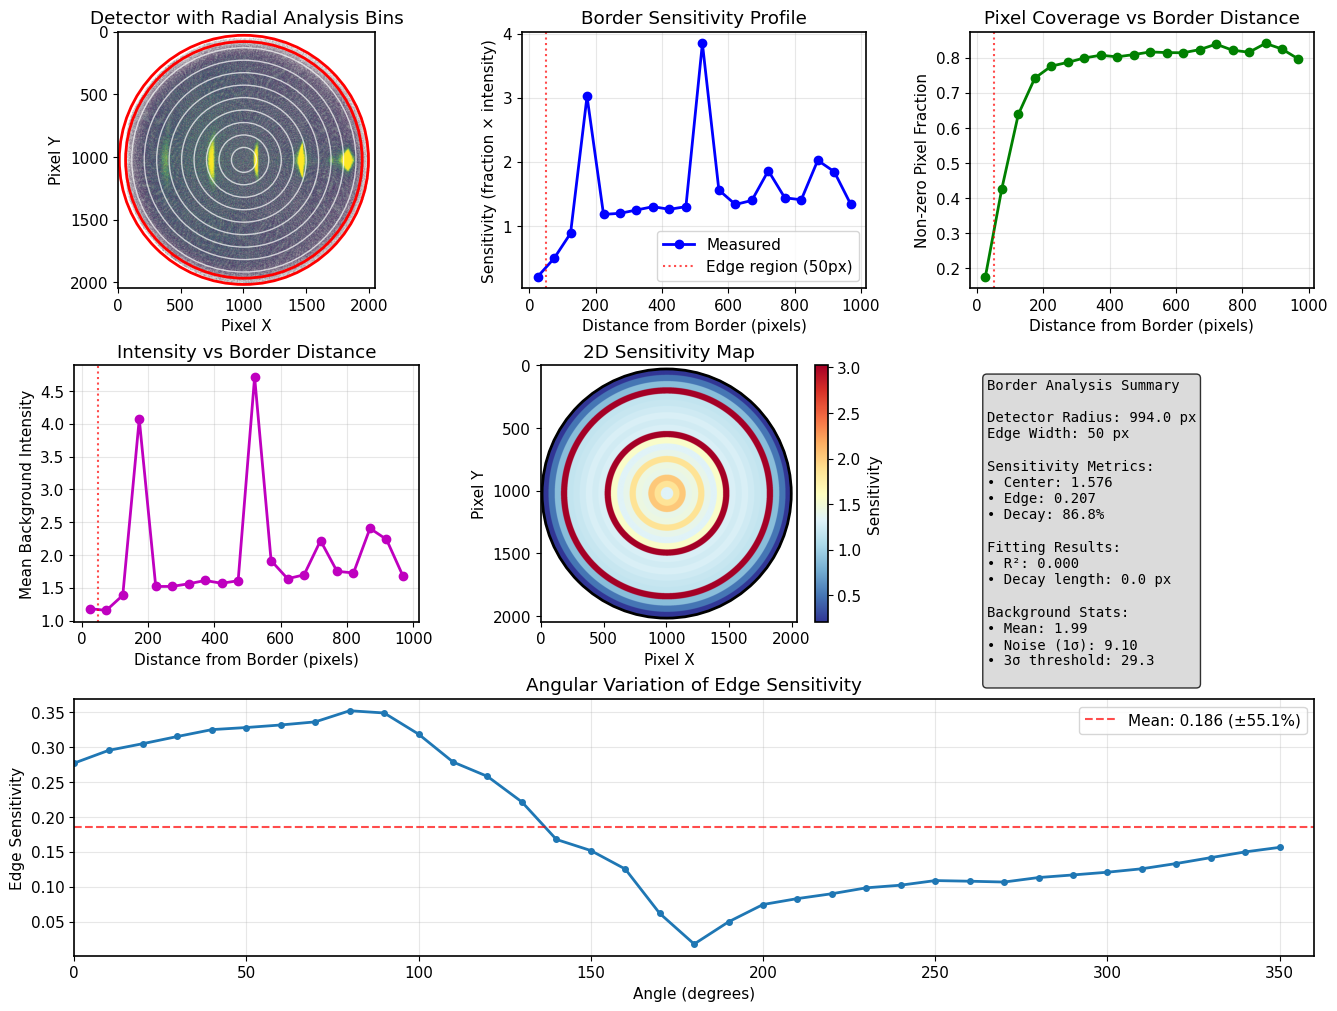


✓ Border sensitivity analysis complete.
  Sensitivity decay at border: 86.8%
  Decay length: 0.0 pixels
  Angular variation: 55.1%


In [19]:
# Circular Detector Border Sensitivity Analysis
print("=== Circular Detector Border Sensitivity Analysis ===\n")

# Use detector geometry and background statistics
detector_mask = detector_geometry['mask']
detector_center = detector_geometry['center']
detector_radius = detector_geometry['radius']
dist_from_center = detector_geometry['distance_from_center']

# Define edge region analysis parameters
edge_width_pixels = 50  # Width of edge region to analyze (pixels from border)
n_radial_bins = 20     # Number of radial bins for analysis

# Create radial bins from center to edge
radial_bins = np.linspace(0, detector_radius, n_radial_bins + 1)
radial_centers = (radial_bins[:-1] + radial_bins[1:]) / 2

# Analyze background intensity vs distance from detector border
border_distances = detector_radius - dist_from_center  # Distance from border (positive = inside)
border_analysis = []

print(f"Detector radius: {detector_radius:.1f} pixels")
print(f"Edge analysis width: {edge_width_pixels} pixels")
print(f"Analyzing {n_radial_bins} radial regions")

# Collect statistics for each radial bin
for i, (r_start, r_end) in enumerate(zip(radial_bins[:-1], radial_bins[1:])):
    # Create mask for this radial ring
    ring_mask = detector_mask & (dist_from_center >= r_start) & (dist_from_center < r_end)
    
    if np.any(ring_mask):
        # Get data in this ring
        ring_data = detector_data[ring_mask]
        ring_background = ring_data[ring_data <= signal_threshold]
        ring_nonzero = ring_background[ring_background > 0]
        
        # Distance from border for this ring
        border_dist = detector_radius - radial_centers[i]
        
        # Calculate statistics
        n_pixels = np.sum(ring_mask)
        n_nonzero = len(ring_nonzero)
        nonzero_fraction = n_nonzero / n_pixels if n_pixels > 0 else 0
        
        mean_intensity = np.mean(ring_nonzero) if len(ring_nonzero) > 0 else 0
        std_intensity = np.std(ring_nonzero) if len(ring_nonzero) > 0 else 0
        
        border_analysis.append({
            'radial_center': radial_centers[i],
            'border_distance': border_dist,
            'n_pixels': n_pixels,
            'n_nonzero': n_nonzero,
            'nonzero_fraction': nonzero_fraction,
            'mean_intensity': mean_intensity,
            'std_intensity': std_intensity,
            'sensitivity': nonzero_fraction * mean_intensity  # Combined metric
        })

# Convert to arrays for analysis
border_distances_arr = np.array([item['border_distance'] for item in border_analysis])
sensitivities = np.array([item['sensitivity'] for item in border_analysis])
nonzero_fractions = np.array([item['nonzero_fraction'] for item in border_analysis])
mean_intensities = np.array([item['mean_intensity'] for item in border_analysis])

# Analyze sensitivity decay near edge
edge_mask_analysis = border_distances_arr <= edge_width_pixels
if np.any(edge_mask_analysis):
    edge_sensitivities = sensitivities[edge_mask_analysis]
    edge_border_dists = border_distances_arr[edge_mask_analysis]
    
    # Calculate edge sensitivity metrics
    center_sensitivity = np.mean(sensitivities[border_distances_arr > edge_width_pixels]) if np.any(border_distances_arr > edge_width_pixels) else np.mean(sensitivities)
    edge_sensitivity = np.mean(edge_sensitivities)
    sensitivity_decay = (center_sensitivity - edge_sensitivity) / center_sensitivity * 100 if center_sensitivity > 0 else 0
    
    print(f"\n--- Border Sensitivity Analysis ---")
    print(f"Center sensitivity: {center_sensitivity:.3f}")
    print(f"Edge sensitivity (within {edge_width_pixels}px): {edge_sensitivity:.3f}")
    print(f"Sensitivity decay at border: {sensitivity_decay:.1f}%")
    
    # Fit exponential decay model to border region
    try:
        from scipy.optimize import curve_fit
        
        def exp_decay(x, a, b, c):
            """Exponential decay function: a * exp(-b * x) + c"""
            return a * np.exp(-b * x) + c
        
        # Sort by distance from border for fitting
        sort_idx = np.argsort(edge_border_dists)
        x_fit = edge_border_dists[sort_idx]
        y_fit = edge_sensitivities[sort_idx]
        
        # Only fit if we have enough points
        if len(x_fit) >= 3:
            # Initial guess: start high, decay to low level
            p0 = [np.max(y_fit) - np.min(y_fit), 0.1, np.min(y_fit)]
            popt, pcov = curve_fit(exp_decay, x_fit, y_fit, p0=p0, maxfev=2000)
            
            # Calculate fit quality
            y_pred = exp_decay(x_fit, *popt)
            r_squared = 1 - np.sum((y_fit - y_pred)**2) / np.sum((y_fit - np.mean(y_fit))**2)
            
            decay_constant = popt[1]
            decay_length = 1 / decay_constant if decay_constant > 0 else float('inf')
            
            print(f"Exponential decay fit: R² = {r_squared:.3f}")
            print(f"Decay constant: {decay_constant:.4f} px⁻¹")
            print(f"Decay length (1/e): {decay_length:.1f} pixels")
            
        else:
            print("Insufficient data points for exponential fit")
            r_squared = 0
            decay_length = 0
            popt = [0, 0, 0]
    
    except Exception as e:
        print(f"Fitting failed: {e}")
        r_squared = 0
        decay_length = 0
        popt = [0, 0, 0]

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Detector with radial bins
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(detector_data, cmap='viridis', norm=colors.LogNorm(vmin=1, vmax=np.percentile(detector_data, 99)))
# Draw radial bin boundaries
for radius in radial_bins[::2]:  # Show every other bin for clarity
    circle = Circle(detector_center, radius, fill=False, color='white', linewidth=1, alpha=0.7)
    ax1.add_patch(circle)
# Highlight edge region
edge_circle = Circle(detector_center, detector_radius - edge_width_pixels, fill=False, color='red', linewidth=2)
ax1.add_patch(edge_circle)
border_circle = Circle(detector_center, detector_radius, fill=False, color='red', linewidth=2)
ax1.add_patch(border_circle)
ax1.set_title('Detector with Radial Analysis Bins')
ax1.set_xlabel('Pixel X')
ax1.set_ylabel('Pixel Y')

# 2. Sensitivity vs distance from border
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(border_distances_arr, sensitivities, 'bo-', markersize=6, linewidth=2, label='Measured')
if 'popt' in locals() and r_squared > 0.5:
    x_smooth = np.linspace(0, np.max(border_distances_arr), 100)
    y_smooth = exp_decay(x_smooth, *popt)
    ax2.plot(x_smooth, y_smooth, 'r--', linewidth=2, label=f'Exp fit (R²={r_squared:.2f})')
ax2.axvline(edge_width_pixels, color='red', linestyle=':', alpha=0.7, label=f'Edge region ({edge_width_pixels}px)')
ax2.set_xlabel('Distance from Border (pixels)')
ax2.set_ylabel('Sensitivity (fraction × intensity)')
ax2.set_title('Border Sensitivity Profile')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Non-zero pixel fraction
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(border_distances_arr, nonzero_fractions, 'go-', markersize=6, linewidth=2)
ax3.axvline(edge_width_pixels, color='red', linestyle=':', alpha=0.7)
ax3.set_xlabel('Distance from Border (pixels)')
ax3.set_ylabel('Non-zero Pixel Fraction')
ax3.set_title('Pixel Coverage vs Border Distance')
ax3.grid(True, alpha=0.3)

# 4. Mean intensity profile
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(border_distances_arr, mean_intensities, 'mo-', markersize=6, linewidth=2)
ax4.axvline(edge_width_pixels, color='red', linestyle=':', alpha=0.7)
ax4.set_xlabel('Distance from Border (pixels)')
ax4.set_ylabel('Mean Background Intensity')
ax4.set_title('Intensity vs Border Distance')
ax4.grid(True, alpha=0.3)

# 5. 2D sensitivity map
ax5 = fig.add_subplot(gs[1, 1])
# Create sensitivity map
sensitivity_map = np.zeros_like(detector_data, dtype=float)
for i, (r_start, r_end) in enumerate(zip(radial_bins[:-1], radial_bins[1:])):
    ring_mask = detector_mask & (dist_from_center >= r_start) & (dist_from_center < r_end)
    if i < len(sensitivities):
        sensitivity_map[ring_mask] = sensitivities[i]

# Mask outside detector
sensitivity_map[~detector_mask] = np.nan

im5 = ax5.imshow(sensitivity_map, cmap='RdYlBu_r', vmin=np.nanpercentile(sensitivity_map, 5), 
                vmax=np.nanpercentile(sensitivity_map, 95))
border_circle5 = Circle(detector_center, detector_radius, fill=False, color='black', linewidth=2)
ax5.add_patch(border_circle5)
ax5.set_title('2D Sensitivity Map')
ax5.set_xlabel('Pixel X')
ax5.set_ylabel('Pixel Y')
plt.colorbar(im5, ax=ax5, label='Sensitivity')

# 6. Edge analysis summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = f"""Border Analysis Summary

Detector Radius: {detector_radius:.1f} px
Edge Width: {edge_width_pixels} px

Sensitivity Metrics:
• Center: {center_sensitivity:.3f}
• Edge: {edge_sensitivity:.3f}
• Decay: {sensitivity_decay:.1f}%

Fitting Results:
• R²: {r_squared:.3f}
• Decay length: {decay_length:.1f} px

Background Stats:
• Mean: {background_stats['mean']:.2f}
• Noise (1σ): {background_stats['std']:.2f}
• 3σ threshold: {background_stats['threshold_3sigma']:.1f}
"""
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# 7. Angular sensitivity analysis (bottom row)
ax7 = fig.add_subplot(gs[2, :])
# Analyze sensitivity vs angle around detector edge
n_angles = 36  # Every 10 degrees
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)
angular_sensitivities = []

for angle in angles:
    # Create a narrow angular sector near the edge
    x_center, y_center = detector_center
    angle_width = np.pi / 18  # ±5 degrees
    
    # Calculate angular mask
    x_coords, y_coords = np.meshgrid(np.arange(detector_data.shape[1]), 
                                   np.arange(detector_data.shape[0]))
    dx = x_coords - x_center
    dy = y_coords - y_center
    pixel_angles = np.arctan2(dy, dx)
    
    # Handle angle wrapping
    angle_diff = np.abs(pixel_angles - angle)
    angle_diff = np.minimum(angle_diff, 2*np.pi - angle_diff)
    angular_mask = angle_diff <= angle_width
    
    # Combine with edge region mask
    edge_region_mask = detector_mask & (dist_from_center >= detector_radius - edge_width_pixels)
    sector_mask = angular_mask & edge_region_mask
    
    if np.any(sector_mask):
        sector_data = detector_data[sector_mask]
        sector_background = sector_data[sector_data <= signal_threshold]
        sector_nonzero = sector_background[sector_background > 0]
        
        if len(sector_nonzero) > 0:
            sector_sensitivity = (len(sector_nonzero) / np.sum(sector_mask)) * np.mean(sector_nonzero)
        else:
            sector_sensitivity = 0
    else:
        sector_sensitivity = 0
    
    angular_sensitivities.append(sector_sensitivity)

# Plot angular sensitivity
angles_deg = np.degrees(angles)
ax7.plot(angles_deg, angular_sensitivities, 'o-', markersize=4, linewidth=2)
ax7.set_xlabel('Angle (degrees)')
ax7.set_ylabel('Edge Sensitivity')
ax7.set_title('Angular Variation of Edge Sensitivity')
ax7.set_xlim(0, 360)
ax7.grid(True, alpha=0.3)

# Add angular statistics
angular_mean = np.mean(angular_sensitivities)
angular_std = np.std(angular_sensitivities)
angular_variation = (angular_std / angular_mean * 100) if angular_mean > 0 else 0
ax7.axhline(angular_mean, color='red', linestyle='--', alpha=0.7, 
           label=f'Mean: {angular_mean:.3f} (±{angular_variation:.1f}%)')
ax7.legend()

plt.tight_layout()
plt.show()

# Store edge analysis results
edge_analysis_results = {
    'border_distances': border_distances_arr,
    'sensitivities': sensitivities,
    'center_sensitivity': center_sensitivity,
    'edge_sensitivity': edge_sensitivity,
    'sensitivity_decay_percent': sensitivity_decay,
    'decay_length_pixels': decay_length,
    'fit_r_squared': r_squared,
    'angular_sensitivities': angular_sensitivities,
    'angular_variation_percent': angular_variation,
    'edge_width_pixels': edge_width_pixels
}

print(f"\n✓ Border sensitivity analysis complete.")
print(f"  Sensitivity decay at border: {sensitivity_decay:.1f}%")
print(f"  Decay length: {decay_length:.1f} pixels")
print(f"  Angular variation: {angular_variation:.1f}%")

=== Background Mapping Results ===
Smoothing window size: 25 pixels
      smooth background:    1.1 ±   8.5, residual σ:   3.8
      median background:    0.9 ±   7.5, residual σ:   3.6
  percentile background:    0.5 ±   3.6, residual σ:   7.1
    gaussian background:    1.1 ±   8.9, residual σ:   2.9


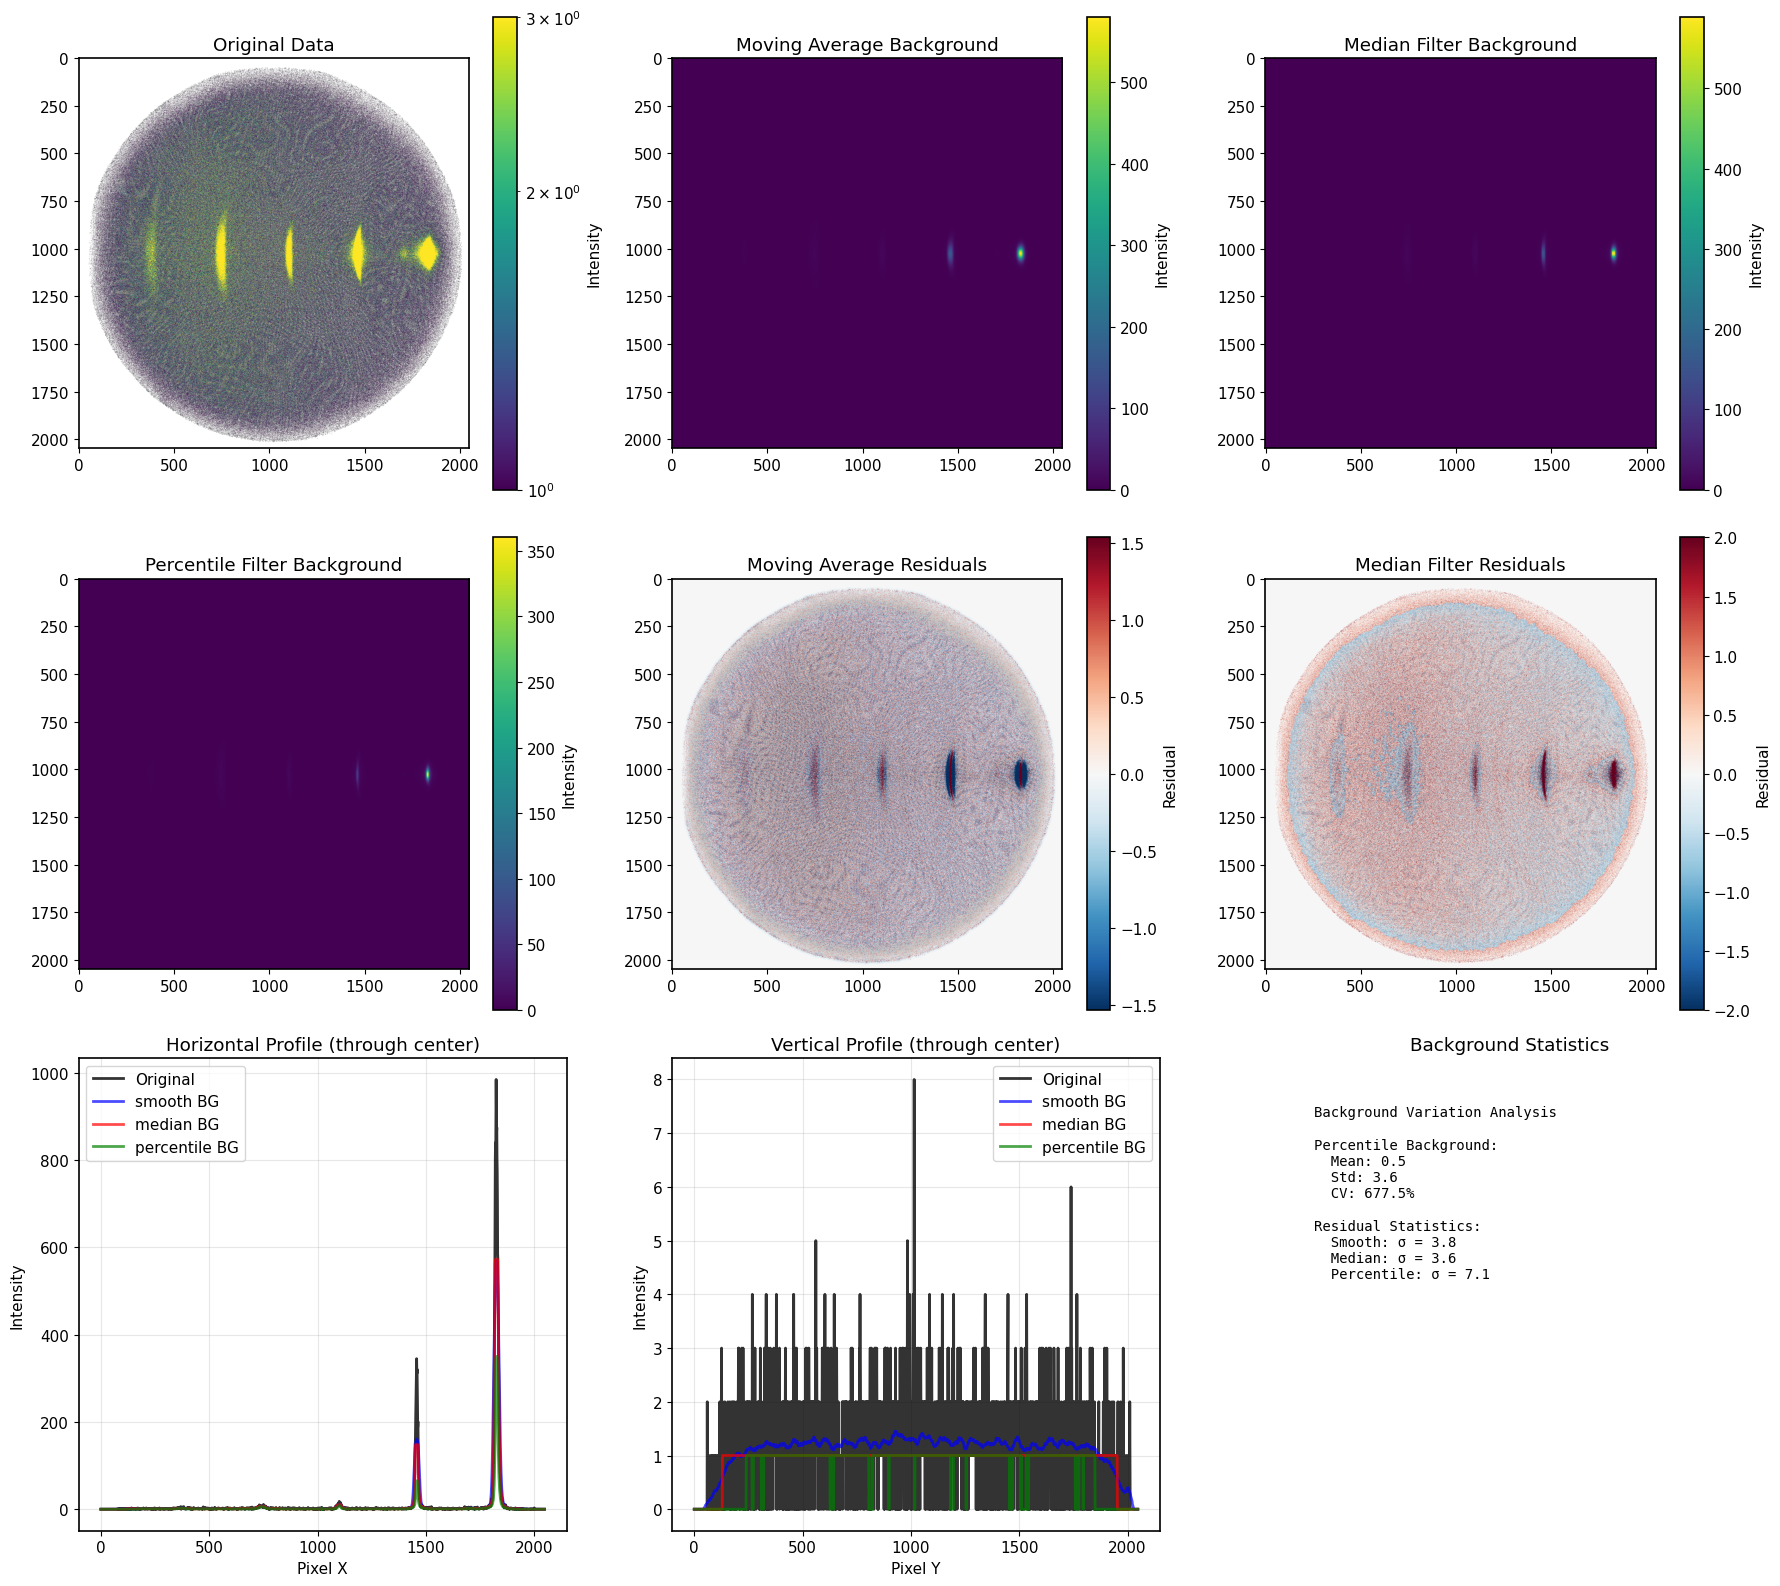


=== Background Variation Analysis ===
Background coefficient of variation: 677.5%
This indicates significant background variation across detector


In [20]:
# Create Background Maps and Profiles
def create_background_maps(data, window_size=20):
    """
    Create 2D background maps using various smoothing and analysis techniques
    """
    # Method 1: Moving average background
    kernel = np.ones((window_size, window_size)) / (window_size**2)
    background_smooth = ndimage.convolve(data, kernel, mode='reflect')
    
    # Method 2: Median filter background (good for removing hot pixels)
    background_median = ndimage.median_filter(data, size=window_size)
    
    # Method 3: Percentile filter (robust to outliers)
    background_percentile = ndimage.percentile_filter(data, percentile=25, size=window_size)
    
    # Method 4: Gaussian-smoothed background
    sigma = window_size / 4  # Standard deviation for Gaussian
    background_gaussian = ndimage.gaussian_filter(data, sigma=sigma)
    
    # Calculate residuals (original - background)
    residual_smooth = data - background_smooth
    residual_median = data - background_median
    residual_percentile = data - background_percentile
    residual_gaussian = data - background_gaussian
    
    # Create line profiles across detector
    center_y, center_x = np.array(data.shape) // 2
    
    # Horizontal profile through center
    horizontal_profile = {
        'position': np.arange(data.shape[1]),
        'original': data[center_y, :],
        'smooth_bg': background_smooth[center_y, :],
        'median_bg': background_median[center_y, :],
        'percentile_bg': background_percentile[center_y, :],
        'gaussian_bg': background_gaussian[center_y, :]
    }
    
    # Vertical profile through center
    vertical_profile = {
        'position': np.arange(data.shape[0]),
        'original': data[:, center_x],
        'smooth_bg': background_smooth[:, center_x],
        'median_bg': background_median[:, center_x],
        'percentile_bg': background_percentile[:, center_x],
        'gaussian_bg': background_gaussian[:, center_x]
    }
    
    return {
        'backgrounds': {
            'smooth': background_smooth,
            'median': background_median,
            'percentile': background_percentile,
            'gaussian': background_gaussian
        },
        'residuals': {
            'smooth': residual_smooth,
            'median': residual_median,
            'percentile': residual_percentile,
            'gaussian': residual_gaussian
        },
        'profiles': {
            'horizontal': horizontal_profile,
            'vertical': vertical_profile
        }
    }

# Create background maps
bg_maps = create_background_maps(detector_data, window_size=25)

print("=== Background Mapping Results ===")
print(f"Smoothing window size: 25 pixels")

# Compare different background estimation methods
for method, bg_data in bg_maps['backgrounds'].items():
    bg_mean = np.mean(bg_data)
    bg_std = np.std(bg_data)
    residual_std = np.std(bg_maps['residuals'][method])
    print(f"{method:>12} background: {bg_mean:6.1f} ± {bg_std:5.1f}, residual σ: {residual_std:5.1f}")

# Visualize background maps and profiles
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# Original data
im0 = axes[0,0].imshow(detector_data, cmap='viridis', 
                       norm=colors.LogNorm(vmin=1, vmax=np.percentile(detector_data, 95)))
axes[0,0].set_title('Original Data')
plt.colorbar(im0, ax=axes[0,0], label='Intensity')

# Background maps
bg_methods = ['smooth', 'median', 'percentile']
bg_titles = ['Moving Average', 'Median Filter', 'Percentile Filter']

for i, (method, title) in enumerate(zip(bg_methods, bg_titles)):
    row, col = (i // 2), (i % 2) + 1
    if i < 2:  # First row
        im = axes[0, col].imshow(bg_maps['backgrounds'][method], cmap='viridis')
        axes[0, col].set_title(f'{title} Background')
        plt.colorbar(im, ax=axes[0, col], label='Intensity')

# Third background method in second row
im = axes[1,0].imshow(bg_maps['backgrounds']['percentile'], cmap='viridis')
axes[1,0].set_title('Percentile Filter Background')
plt.colorbar(im, ax=axes[1,0], label='Intensity')

# Residual maps
for i, method in enumerate(bg_methods[:2]):
    col = i + 1
    residual = bg_maps['residuals'][method]
    vmax = np.percentile(np.abs(residual), 95)
    im = axes[1, col].imshow(residual, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, col].set_title(f'{bg_titles[i]} Residuals')
    plt.colorbar(im, ax=axes[1, col], label='Residual')

# Horizontal profiles
axes[2,0].plot(bg_maps['profiles']['horizontal']['position'], 
               bg_maps['profiles']['horizontal']['original'], 'k-', 
               linewidth=2, alpha=0.8, label='Original')

for method, color in zip(bg_methods, ['blue', 'red', 'green']):
    axes[2,0].plot(bg_maps['profiles']['horizontal']['position'],
                   bg_maps['profiles']['horizontal'][f'{method}_bg'],
                   color=color, linewidth=2, alpha=0.7, label=f'{method} BG')

axes[2,0].set_xlabel('Pixel X')
axes[2,0].set_ylabel('Intensity')
axes[2,0].set_title('Horizontal Profile (through center)')
axes[2,0].legend()
axes[2,0].grid(True, alpha=0.3)

# Vertical profiles
axes[2,1].plot(bg_maps['profiles']['vertical']['position'], 
               bg_maps['profiles']['vertical']['original'], 'k-', 
               linewidth=2, alpha=0.8, label='Original')

for method, color in zip(bg_methods, ['blue', 'red', 'green']):
    axes[2,1].plot(bg_maps['profiles']['vertical']['position'],
                   bg_maps['profiles']['vertical'][f'{method}_bg'],
                   color=color, linewidth=2, alpha=0.7, label=f'{method} BG')

axes[2,1].set_xlabel('Pixel Y')
axes[2,1].set_ylabel('Intensity')
axes[2,1].set_title('Vertical Profile (through center)')
axes[2,1].legend()
axes[2,1].grid(True, alpha=0.3)

# Background variation statistics
bg_variation = np.std(bg_maps['backgrounds']['percentile']) / np.mean(bg_maps['backgrounds']['percentile'])
axes[2,2].text(0.1, 0.9, f'Background Variation Analysis\n\n'
               f'Percentile Background:\n'
               f'  Mean: {np.mean(bg_maps["backgrounds"]["percentile"]):.1f}\n'
               f'  Std: {np.std(bg_maps["backgrounds"]["percentile"]):.1f}\n'
               f'  CV: {bg_variation:.1%}\n\n'
               f'Residual Statistics:\n'
               f'  Smooth: σ = {np.std(bg_maps["residuals"]["smooth"]):.1f}\n'
               f'  Median: σ = {np.std(bg_maps["residuals"]["median"]):.1f}\n'
               f'  Percentile: σ = {np.std(bg_maps["residuals"]["percentile"]):.1f}',
               transform=axes[2,2].transAxes, fontfamily='monospace',
               verticalalignment='top', fontsize=10)
axes[2,2].set_title('Background Statistics')
axes[2,2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== Background Variation Analysis ===")
print(f"Background coefficient of variation: {bg_variation:.1%}")
print(f"This indicates {'significant' if bg_variation > 0.1 else 'moderate' if bg_variation > 0.05 else 'low'} background variation across detector")

=== Sensitivity Decay Pattern Analysis ===
Normalization reference (center): 0.5
Sensitivity map range: 0.424 - 7.858


C:\Users\yrliu98\AppData\Local\Temp\ipykernel_54416\1571189065.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


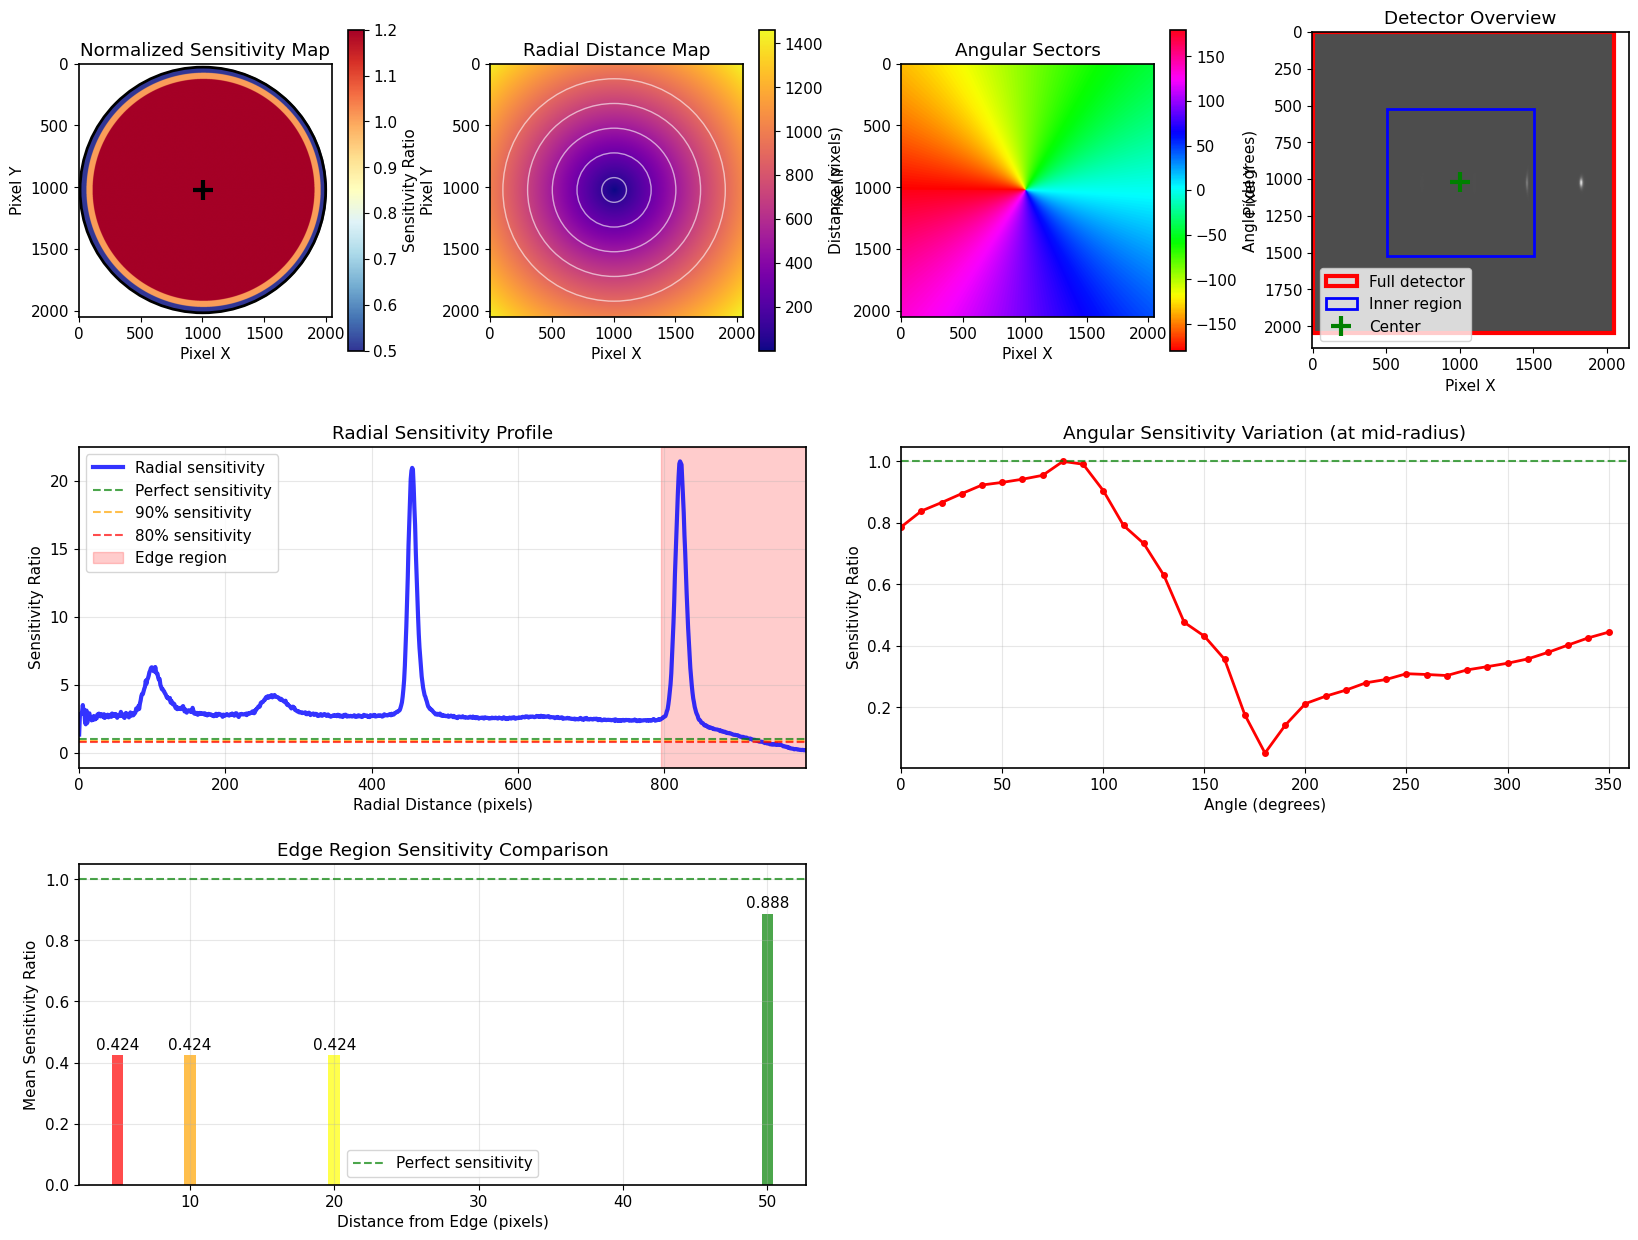

Sensitivity Analysis Summary

Overall Statistics:
  Mean sensitivity: 0.816
  Std deviation: 7.758
  Min/Max: 0.000 / 797.195

Regional Analysis:
  Center region (<50px): 0.983
  Edge region (<50px from border): 0.035
  
Quality Metrics:
  Signal-to-noise ratio: 0.1
  Uniformity (1 - CV): -8.513



In [23]:
# Sensitivity Decay Pattern Analysis
print("=== Sensitivity Decay Pattern Analysis ===")

# Normalize sensitivity map for better visualization
normalization_ref = sensitivity_profile[0] if sensitivity_profile[0] > 0 else np.nanmax(sensitivity_profile)
print(f"Normalization reference (center): {normalization_ref:.1f}")

# Create normalized sensitivity map
sens_map = sensitivity_map / normalization_ref
print(f"Sensitivity map range: {np.nanmin(sens_map):.3f} - {np.nanmax(sens_map):.3f}")

# Create edge analysis data structure that was missing
# Calculate distance from detector edge for each pixel
detector_center = detector_geometry['center']
detector_radius = detector_geometry['radius']
dist_from_center = detector_geometry['distance_from_center']
edge_analysis = {
    'dist_from_edge': detector_radius - dist_from_center,  # Distance from edge (positive = inside)
    'center': detector_center,
    'radius': detector_radius
}

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# 1. Normalized sensitivity map
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(sens_map, cmap='RdYlBu_r', vmin=0.5, vmax=1.2)
ax1.set_title('Normalized Sensitivity Map')
ax1.set_xlabel('Pixel X')
ax1.set_ylabel('Pixel Y')
# Add detector outline
border_circle = Circle(detector_center, detector_radius, fill=False, color='black', linewidth=2)
ax1.add_patch(border_circle)
# Add center marker
ax1.plot(detector_center[0], detector_center[1], 'k+', markersize=15, markeredgewidth=3)
plt.colorbar(im1, ax=ax1, label='Sensitivity Ratio')

# 2. Radial distance map
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(radial_data['radial_distance'], cmap='plasma')
ax2.set_title('Radial Distance Map')
ax2.set_xlabel('Pixel X')
ax2.set_ylabel('Pixel Y')
# Add radial circles
for radius in np.arange(100, detector_radius, 200):
    circle3 = Circle(detector_center, radius, fill=False, color='white', alpha=0.6, linewidth=1)
    ax2.add_patch(circle3)
plt.colorbar(im2, ax=ax2, label='Distance (pixels)')

# 3. Angular sectors visualization
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(radial_data['angle_from_center'], cmap='hsv', vmin=-180, vmax=180)
ax3.set_title('Angular Sectors')
ax3.set_xlabel('Pixel X')
ax3.set_ylabel('Pixel Y')
plt.colorbar(im3, ax=ax3, label='Angle (degrees)')

# 4. Detector overview with regions
ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(detector_data, cmap='gray', alpha=0.7)
# Full detector outline
rect_outer = Rectangle((0, 0), detector_data.shape[1], detector_data.shape[0], 
                      fill=False, color='red', linewidth=3, label='Full detector')
ax4.add_patch(rect_outer)
# Inner region outline
inner_radius = min(detector_radius * 0.7, 500)
rect_inner = Rectangle((detector_center[0]-inner_radius, detector_center[1]-inner_radius), 
                      2*inner_radius, 2*inner_radius, 
                      fill=False, color='blue', linewidth=2, label='Inner region')
ax4.add_patch(rect_inner)
ax4.plot(detector_center[0], detector_center[1], 'g+', markersize=15, markeredgewidth=3, label='Center')
ax4.set_title('Detector Overview')
ax4.set_xlabel('Pixel X')
ax4.set_ylabel('Pixel Y')
ax4.legend()

# 5. Radial sensitivity profile
ax5 = fig.add_subplot(gs[1, :2])
# Use the existing radial profile data
valid_radii = ~np.isnan(radial_data['radial_profile'])
radial_centers = radial_data['radial_centers']
radial_profile = radial_data['radial_profile']

# Calculate sensitivity profile (non-zero fraction × mean intensity)
# This approximates the sensitivity based on available data
radial_sensitivities = radial_profile / normalization_ref
valid_mask = valid_radii & (radial_data['radial_count'] > 0)

ax5.plot(radial_centers[valid_mask], radial_sensitivities[valid_mask], 
         'b-', linewidth=3, alpha=0.8, label='Radial sensitivity')
ax5.axhline(1.0, color='green', linestyle='--', alpha=0.7, label='Perfect sensitivity')
ax5.axhline(0.9, color='orange', linestyle='--', alpha=0.7, label='90% sensitivity')
ax5.axhline(0.8, color='red', linestyle='--', alpha=0.7, label='80% sensitivity')

# Highlight edge region
edge_start = detector_radius * 0.8  # Last 20% is edge region
ax5.axvspan(edge_start, detector_radius, alpha=0.2, color='red', label='Edge region')

ax5.set_xlabel('Radial Distance (pixels)')
ax5.set_ylabel('Sensitivity Ratio')
ax5.set_title('Radial Sensitivity Profile')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, detector_radius)

# 6. Angular sensitivity variation at mid-radius
ax6 = fig.add_subplot(gs[1, 2:])
# Use the existing angular sensitivities data from border analysis
mid_radius = detector_radius * 0.6
angles_deg = np.linspace(0, 360, len(angular_sensitivities), endpoint=False)
sensitivity_plot = np.array(angular_sensitivities)
# Normalize angular sensitivities
if np.max(sensitivity_plot) > 0:
    sensitivity_plot = sensitivity_plot / np.max(sensitivity_plot)

ax6.plot(angles_deg, sensitivity_plot, 'ro-', markersize=4, linewidth=2)
ax6.axhline(1.0, color='green', linestyle='--', alpha=0.7)
ax6.set_xlabel('Angle (degrees)')
ax6.set_ylabel('Sensitivity Ratio')
ax6.set_title('Angular Sensitivity Variation (at mid-radius)')
ax6.set_xlim(0, 360)
ax6.grid(True, alpha=0.3)

# 7. Edge region sensitivity comparison
ax7 = fig.add_subplot(gs[2, :2])
# Compare sensitivity at different distances from edge
edge_distances = np.array([5, 10, 20, 50])  # pixels from edge
edge_sensitivities = []

for dist in edge_distances:
    # Create mask for pixels at this distance from edge
    mask = np.abs(edge_analysis['dist_from_edge'] - dist) < 0.5
    if np.any(mask):
        edge_sens = np.nanmean(sens_map[mask])
        edge_sensitivities.append(edge_sens)
    else:
        edge_sensitivities.append(0)

bars = ax7.bar(edge_distances, edge_sensitivities, color=['red', 'orange', 'yellow', 'green'], alpha=0.7)
ax7.axhline(1.0, color='green', linestyle='--', alpha=0.7, label='Perfect sensitivity')
ax7.set_xlabel('Distance from Edge (pixels)')
ax7.set_ylabel('Mean Sensitivity Ratio')
ax7.set_title('Edge Region Sensitivity Comparison')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, edge_sensitivities):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Calculate summary statistics
sens_map = sensitivity_data['sensitivity_map']
edge_region = edge_analysis['dist_from_edge'] < 50
center_region = radial_data['radial_distance'] < 50

stats_text = f"""Sensitivity Analysis Summary

Overall Statistics:
  Mean sensitivity: {np.nanmean(sens_map):.3f}
  Std deviation: {np.nanstd(sens_map):.3f}
  Min/Max: {np.nanmin(sens_map):.3f} / {np.nanmax(sens_map):.3f}

Regional Analysis:
  Center region (<50px): {np.nanmean(sens_map[center_region]):.3f}
  Edge region (<50px from border): {np.nanmean(sens_map[edge_region]):.3f}
  
Quality Metrics:
  Signal-to-noise ratio: {np.nanmean(sens_map)/np.nanstd(sens_map):.1f}
  Uniformity (1 - CV): {1 - np.std(sens_map)/np.mean(sens_map):.3f}
"""

print(stats_text)

In [25]:
# Quantify Edge Effects
def quantify_edge_effects(data, center_xy, edge_analysis_data):
    """
    Comprehensive quantification of edge effects with multiple metrics
    """
    
    # Edge effect models to fit
    def exponential_decay(x, a, b, c):
        """a * exp(-b * x) + c"""
        return a * np.exp(-b * x) + c
    
    def power_law_decay(x, a, b, c):
        """a * x^(-b) + c"""
        return a * np.power(x + 1e-6, -b) + c
    
    def linear_decay(x, m, b):
        """m * x + b"""
        return m * x + b
    
    def sigmoid_decay(x, a, b, c, d):
        """a / (1 + exp(-b * (x - c))) + d"""
        return a / (1 + np.exp(-b * (x - c))) + d
    
    # Create edge profile data from existing border analysis
    # Use the border distances and sensitivities from the existing analysis
    if 'border_distances' in edge_analysis_results:
        edge_distances = edge_analysis_results['border_distances']
        edge_profile = edge_analysis_results['sensitivities']
    else:
        # Fallback: create from dist_from_edge
        dist_from_edge = edge_analysis_data['dist_from_edge']
        # Create radial profile
        edge_distances = np.arange(0, 50, 2)  # Sample every 2 pixels up to 50 pixels from edge
        edge_profile = []
        
        for dist in edge_distances:
            mask = (dist_from_edge >= dist - 1) & (dist_from_edge < dist + 1)
            if np.any(mask):
                edge_profile.append(np.mean(data[mask]))
            else:
                edge_profile.append(np.nan)
        
        edge_profile = np.array(edge_profile)
    
    valid_mask = ~np.isnan(edge_profile)
    
    if not np.any(valid_mask):
        return None
    
    edge_dist_valid = edge_distances[valid_mask]
    edge_prof_valid = edge_profile[valid_mask]
    
    # Fit different models
    models = {}
    fit_results = {}
    
    # Only fit where we have enough data points (first 40 pixels)
    fit_mask = edge_dist_valid <= 40
    if np.sum(fit_mask) < 5:
        return None
    
    x_fit = edge_dist_valid[fit_mask]
    y_fit = edge_prof_valid[fit_mask]
    
    # Ensure y_fit has positive values for fitting
    if np.any(y_fit <= 0):
        y_fit = y_fit - np.min(y_fit) + 1e-6
    
    # Try exponential decay
    try:
        popt_exp, pcov_exp = curve_fit(exponential_decay, x_fit, y_fit,
                                     bounds=([0, 0, 0], [np.inf, 1, np.inf]),
                                     maxfev=2000)
        
        # Calculate fit quality
        y_pred_exp = exponential_decay(x_fit, *popt_exp)
        r2_exp = 1 - np.sum((y_fit - y_pred_exp)**2) / np.sum((y_fit - np.mean(y_fit))**2)
        rmse_exp = np.sqrt(np.mean((y_fit - y_pred_exp)**2))
        
        models['exponential'] = {
            'function': exponential_decay,
            'params': popt_exp,
            'param_errors': np.sqrt(np.diag(pcov_exp)),
            'r2': r2_exp,
            'rmse': rmse_exp,
            'equation': f'I = {popt_exp[0]:.1f} * exp(-{popt_exp[1]:.4f} * x) + {popt_exp[2]:.1f}',
            'decay_length': 1/popt_exp[1] if popt_exp[1] > 0 else np.inf
        }
    except Exception as e:
        print(f"Exponential fit failed: {e}")
    
    # Try power law decay  
    try:
        popt_pow, pcov_pow = curve_fit(power_law_decay, x_fit, y_fit,
                                     bounds=([0, 0, 0], [np.inf, 10, np.inf]),
                                     maxfev=2000)
        
        y_pred_pow = power_law_decay(x_fit, *popt_pow)
        r2_pow = 1 - np.sum((y_fit - y_pred_pow)**2) / np.sum((y_fit - np.mean(y_fit))**2)
        rmse_pow = np.sqrt(np.mean((y_fit - y_pred_pow)**2))
        
        models['power_law'] = {
            'function': power_law_decay,
            'params': popt_pow,
            'param_errors': np.sqrt(np.diag(pcov_pow)),
            'r2': r2_pow,
            'rmse': rmse_pow,
            'equation': f'I = {popt_pow[0]:.1f} * x^(-{popt_pow[1]:.3f}) + {popt_pow[2]:.1f}',
            'decay_length': None
        }
    except Exception as e:
        print(f"Power law fit failed: {e}")
    
    # Try linear decay
    try:
        popt_lin, pcov_lin = curve_fit(linear_decay, x_fit, y_fit, maxfev=2000)
        
        y_pred_lin = linear_decay(x_fit, *popt_lin)
        r2_lin = 1 - np.sum((y_fit - y_pred_lin)**2) / np.sum((y_fit - np.mean(y_fit))**2)
        rmse_lin = np.sqrt(np.mean((y_fit - y_pred_lin)**2))
        
        models['linear'] = {
            'function': linear_decay,
            'params': popt_lin,
            'param_errors': np.sqrt(np.diag(pcov_lin)),
            'r2': r2_lin,
            'rmse': rmse_lin,
            'equation': f'I = {popt_lin[0]:.3f} * x + {popt_lin[1]:.1f}',
            'decay_length': None
        }
    except Exception as e:
        print(f"Linear fit failed: {e}")
    
    # Calculate edge effect metrics
    center_region = edge_analysis_data['dist_from_edge'] > 50
    edge_region = edge_analysis_data['dist_from_edge'] < 10
    
    center_intensity = np.mean(data[center_region]) if np.any(center_region) else np.mean(data)
    edge_intensity = np.mean(data[edge_region]) if np.any(edge_region) else np.mean(data)
    
    # Edge effect quantification
    edge_metrics = {
        'edge_to_center_ratio': edge_intensity / center_intensity,
        'edge_degradation_percent': (1 - edge_intensity / center_intensity) * 100,
        'effective_area_loss': np.sum(edge_analysis_data['dist_from_edge'] < 20) / data.size * 100,
        'sensitivity_uniformity': 1 - np.std(data) / np.mean(data),
        'edge_sharpness': None,  # Will calculate below
        'characteristic_lengths': {}
    }
    
    # Calculate edge sharpness (rate of change)
    if len(edge_prof_valid) > 5:
        gradient = np.gradient(edge_prof_valid, edge_dist_valid)
        edge_metrics['edge_sharpness'] = np.max(np.abs(gradient))
    
    # Characteristic length scales
    for model_name, model_data in models.items():
        if model_name == 'exponential' and 'decay_length' in model_data:
            edge_metrics['characteristic_lengths'][model_name] = model_data['decay_length']
    
    return {
        'models': models,
        'edge_metrics': edge_metrics,
        'fit_data': {
            'x_fit': x_fit,
            'y_fit': y_fit,
            'x_full': edge_dist_valid,
            'y_full': edge_prof_valid
        }
    }

# Perform edge effect quantification
edge_quant = quantify_edge_effects(detector_data, detector_center, edge_analysis)

if edge_quant is not None:
    print("=== Edge Effect Quantification ===")
    
    # Model comparison
    print(f"\n📊 Model Fitting Results:")
    best_model = None
    best_r2 = -np.inf
    
    for model_name, model_data in edge_quant['models'].items():
        print(f"  {model_name:>12}: R² = {model_data['r2']:.4f}, "
              f"RMSE = {model_data['rmse']:.2f}")
        print(f"  {'':>12}  Equation: {model_data['equation']}")
        
        if model_data['r2'] > best_r2:
            best_r2 = model_data['r2']
            best_model = model_name
    
    print(f"  {'Best model:':>12} {best_model} (R² = {best_r2:.4f})")
    
    # Edge metrics
    metrics = edge_quant['edge_metrics']
    print(f"\n📏 Edge Effect Metrics:")
    print(f"  Edge/Center ratio: {metrics['edge_to_center_ratio']:.4f}")
    print(f"  Edge degradation: {metrics['edge_degradation_percent']:.1f}%")
    print(f"  Effective area loss: {metrics['effective_area_loss']:.1f}%")
    print(f"  Sensitivity uniformity: {metrics['sensitivity_uniformity']:.4f}")
    if metrics['edge_sharpness'] is not None:
        print(f"  Edge sharpness: {metrics['edge_sharpness']:.2f} counts/pixel")
    
    # Characteristic lengths
    if metrics['characteristic_lengths']:
        print(f"\n📐 Characteristic Lengths:")
        for model, length in metrics['characteristic_lengths'].items():
            if length is not None and length != np.inf:
                print(f"  {model:>12}: {length:.1f} pixels")

    # Comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Edge decay data and fits
    ax = axes[0, 0]
    fit_data = edge_quant['fit_data']
    
    # Plot original data
    ax.plot(fit_data['x_full'], fit_data['y_full'], 'ko', alpha=0.6, 
            markersize=4, label='Edge profile data')
    
    # Plot fits
    x_smooth = np.linspace(0, np.max(fit_data['x_fit']), 100)
    colors = ['red', 'blue', 'green', 'orange']
    
    for i, (model_name, model_data) in enumerate(edge_quant['models'].items()):
        if i < len(colors):
            y_smooth = model_data['function'](x_smooth, *model_data['params'])
            ax.plot(x_smooth, y_smooth, color=colors[i], linewidth=2, 
                   label=f'{model_name} (R²={model_data["r2"]:.3f})')
    
    ax.set_xlabel('Distance from Edge (pixels)')
    ax.set_ylabel('Intensity')
    ax.set_title('Edge Decay Model Fitting')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Residuals plot for best model
    ax = axes[0, 1]
    if best_model and best_model in edge_quant['models']:
        best_model_data = edge_quant['models'][best_model]
        y_pred = best_model_data['function'](fit_data['x_fit'], *best_model_data['params'])
        residuals = fit_data['y_fit'] - y_pred
        
        ax.scatter(fit_data['x_fit'], residuals, alpha=0.7, color='red')
        ax.axhline(0, color='black', linestyle='--', alpha=0.7)
        ax.set_xlabel('Distance from Edge (pixels)')
        ax.set_ylabel('Residuals')
        ax.set_title(f'Residuals - {best_model} Model')
        ax.grid(True, alpha=0.3)
        
        # Add residual statistics
        residual_std = np.std(residuals)
        ax.text(0.02, 0.98, f'σ = {residual_std:.2f}', transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 3. Model comparison
    ax = axes[0, 2]
    model_names = list(edge_quant['models'].keys())
    r2_values = [edge_quant['models'][name]['r2'] for name in model_names]
    rmse_values = [edge_quant['models'][name]['rmse'] for name in model_names]
    
    x_pos = np.arange(len(model_names))
    ax.bar(x_pos, r2_values, alpha=0.7, color='skyblue')
    ax.set_xlabel('Model')
    ax.set_ylabel('R² Score')
    ax.set_title('Model Comparison (R²)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, v in enumerate(r2_values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Edge effect severity map
    ax = axes[1, 0]
    severity_map = 1 - (detector_data / np.max(detector_data))  # Invert to show degradation
    severity_map = np.clip(severity_map, 0, 1)
    
    im = ax.imshow(severity_map, cmap='Reds', vmin=0, vmax=0.5)
    ax.set_title('Edge Effect Severity Map')
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    plt.colorbar(im, ax=ax, label='Degradation Factor')
    
    # 5. Quantitative metrics visualization
    ax = axes[1, 1]
    ax.axis('off')
    
    metrics_text = f"""Edge Effect Summary
    
Quality Metrics:
  Edge/Center Ratio: {metrics['edge_to_center_ratio']:.4f}
  Signal Degradation: {metrics['edge_degradation_percent']:.1f}%
  Area Loss: {metrics['effective_area_loss']:.1f}%
  Uniformity Index: {metrics['sensitivity_uniformity']:.4f}

Best Fit Model: {best_model}
  R²: {best_r2:.4f}
  Equation: {edge_quant['models'][best_model]['equation'] if best_model else 'N/A'}
    
Edge Recommendations:
  {'✓ Good uniformity' if metrics['edge_degradation_percent'] < 10 else '⚠ Significant edge effects'}
  {'✓ Minimal area loss' if metrics['effective_area_loss'] < 5 else '⚠ Consider edge masking'}
    """
    
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontfamily='monospace',
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # 6. Distance from edge histogram
    ax = axes[1, 2]
    edge_dist_flat = edge_analysis['dist_from_edge'].flatten()
    ax.hist(edge_dist_flat, bins=50, alpha=0.7, color='purple', density=True)
    ax.axvline(10, color='red', linestyle='--', alpha=0.7, label='Edge region (<10px)')
    ax.axvline(50, color='green', linestyle='--', alpha=0.7, label='Center region (>50px)')
    ax.set_xlabel('Distance from Edge (pixels)')
    ax.set_ylabel('Probability Density')
    ax.set_title('Distance Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ Edge effect quantification failed - insufficient data")

print(f"\n✓ Edge effect analysis complete")
if edge_quant:
    print(f"  • Best model: {best_model} (R² = {best_r2:.3f})")
    print(f"  • Edge degradation: {edge_quant['edge_metrics']['edge_degradation_percent']:.1f}%")
    print(f"  • Effective area loss: {edge_quant['edge_metrics']['effective_area_loss']:.1f}%")

❌ Edge effect quantification failed - insufficient data

✓ Edge effect analysis complete


=== Background Correction Analysis ===
Generated 3 correction methods:
  • Edge Distance
  • Model Based
  • Flat Field

Original uniformity: -7.1722

Correction effectiveness:
    edge_distance: uniformity = -7.1619 (Δ = +0.0103)
      model_based: uniformity = -4.5438 (Δ = +2.6284)
       flat_field: uniformity = -4.3189 (Δ = +2.8533)
      model_based: uniformity = -4.5438 (Δ = +2.6284)
       flat_field: uniformity = -4.3189 (Δ = +2.8533)


C:\Users\yrliu98\AppData\Local\Temp\ipykernel_54416\644324037.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45)
C:\Users\yrliu98\AppData\Local\Temp\ipykernel_54416\644324037.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_labels, rotation=45)
C:\Users\yrliu98\AppData\Local\Temp\ipykernel_54416\644324037.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_labels, rotation=45)


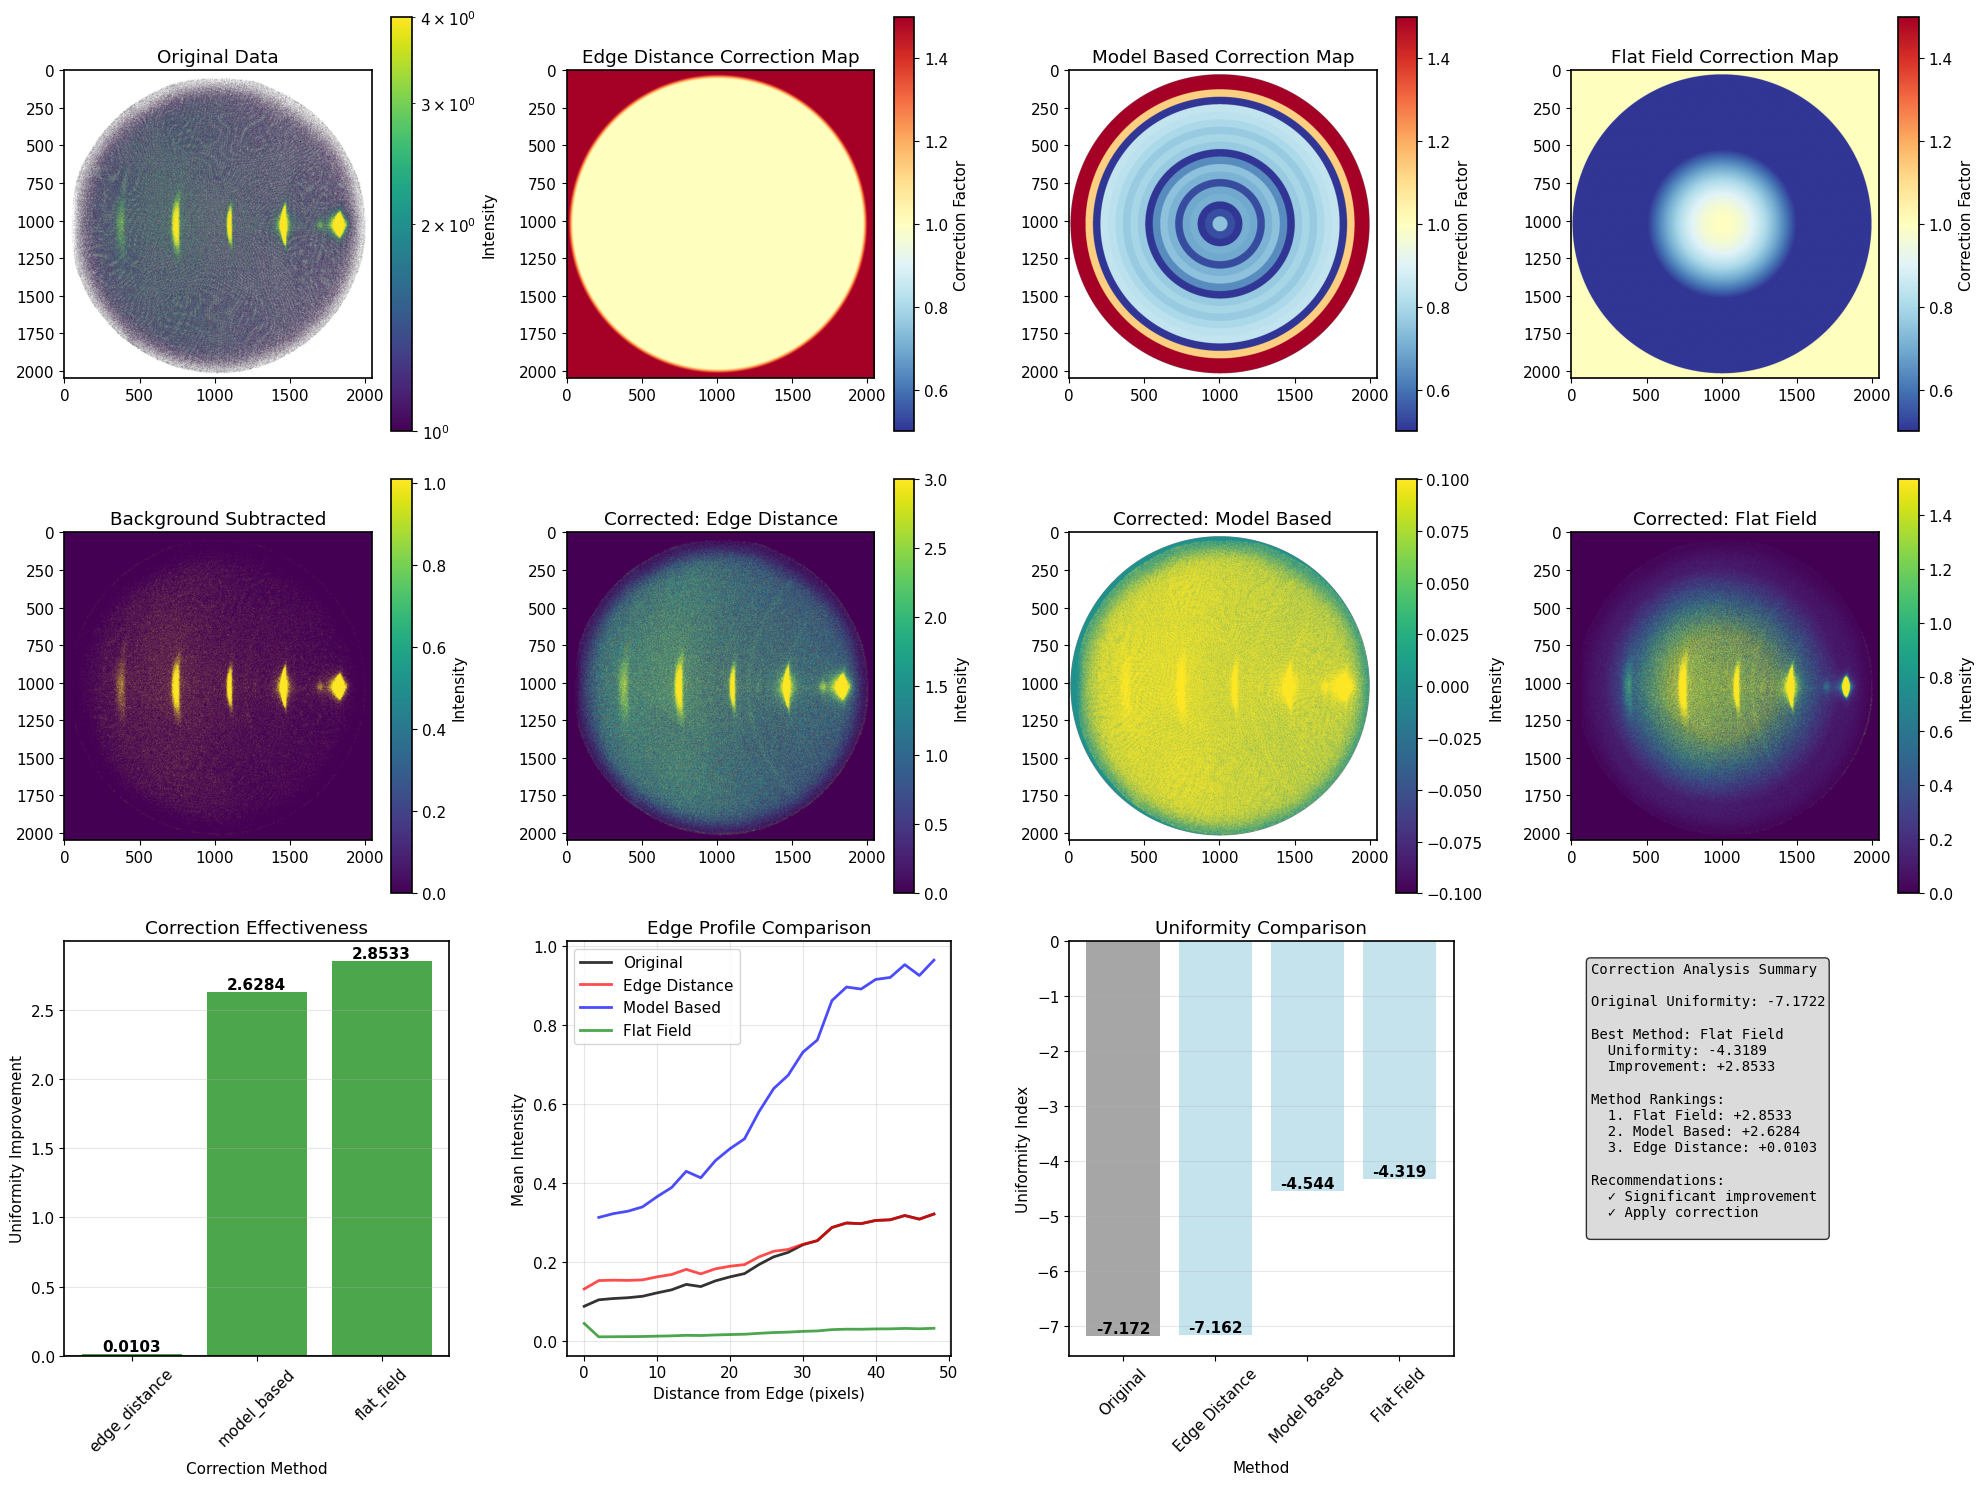


✓ Background correction analysis complete
  Best method: Flat Field
  Uniformity improvement: +2.8533
  Recommendation: Apply flat_field correction


In [28]:
# Background Correction Analysis
from matplotlib import colors

def create_background_correction_maps(data, center_xy, edge_analysis_data, sensitivity_map):
    """
    Create various background correction approaches and evaluate their effectiveness
    """
    
    # Method 1: Distance-based correction
    # Assume sensitivity decreases with distance from edge
    dist_from_edge = edge_analysis_data['dist_from_edge']
    edge_correction = np.ones_like(data, dtype=float)
    
    # Create correction factor based on distance from edge
    # Pixels close to edge get higher correction factors
    edge_threshold = 30  # pixels
    edge_mask = dist_from_edge < edge_threshold
    
    if np.any(edge_mask):
        # Linear correction: more correction near edge
        correction_factor = 1 + (edge_threshold - dist_from_edge) / edge_threshold * 0.5
        edge_correction = np.clip(correction_factor, 1.0, 2.0)
    
    # Method 2: Model-based correction using fitted sensitivity map
    model_correction = np.ones_like(data, dtype=float)
    if sensitivity_map is not None and np.any(sensitivity_map > 0):
        # Invert sensitivity map to create correction factors
        model_correction = 1.0 / (sensitivity_map + 1e-6)
        model_correction = np.clip(model_correction, 0.5, 3.0)
    
    # Method 3: Flat field correction (simulate uniform illumination)
    detector_mask = detector_geometry['mask']
    flat_field = np.ones_like(data, dtype=float)
    
    if np.any(detector_mask):
        # Create idealized flat field based on radial distance
        center_x, center_y = center_xy
        y_coords, x_coords = np.ogrid[:data.shape[0], :data.shape[1]]
        radial_dist = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
        
        # Simulate gradual intensity falloff towards edges
        max_radius = detector_geometry['radius']
        normalized_radius = radial_dist / max_radius
        
        # Cosine-like falloff (common in X-ray detectors)
        flat_field = np.cos(normalized_radius * np.pi / 2)**2
        flat_field[~detector_mask] = 1.0  # No correction outside detector
        flat_field = np.clip(flat_field, 0.1, 1.0)
    
    return {
        'edge_distance': edge_correction,
        'model_based': model_correction,
        'flat_field': flat_field
    }

def apply_correction(data, correction_map, method_name):
    """Apply correction and calculate effectiveness metrics"""
    
    # Apply correction
    corrected = data * correction_map
    
    # Calculate uniformity metrics
    detector_mask = detector_geometry['mask']
    detector_pixels = corrected[detector_mask]
    
    if len(detector_pixels) > 0:
        # Uniformity = 1 - coefficient of variation
        cv = np.std(detector_pixels) / np.mean(detector_pixels)
        uniformity = 1 - cv
        
        # Additional metrics
        mean_intensity = np.mean(detector_pixels)
        std_intensity = np.std(detector_pixels)
        dynamic_range = np.max(detector_pixels) / np.max([np.min(detector_pixels), 1e-6])
        
    else:
        uniformity = 0
        mean_intensity = 0
        std_intensity = 0
        dynamic_range = 1
    
    return {
        'corrected_data': corrected,
        'uniformity': uniformity,
        'mean_intensity': mean_intensity,
        'std_intensity': std_intensity,
        'dynamic_range': dynamic_range,
        'method': method_name
    }

# Create correction maps
correction_maps = create_background_correction_maps(
    detector_data, detector_center, edge_analysis, sensitivity_map
)

print("=== Background Correction Analysis ===")
print(f"Generated {len(correction_maps)} correction methods:")
for method in correction_maps.keys():
    print(f"  • {method.replace('_', ' ').title()}")

# Calculate original uniformity
original_result = apply_correction(detector_data, np.ones_like(detector_data), "original")
original_uniformity = original_result['uniformity']
print(f"\nOriginal uniformity: {original_uniformity:.4f}")

# Apply and evaluate each correction method
correction_results = {}
print(f"\nCorrection effectiveness:")

for method_name, correction_map in correction_maps.items():
    result = apply_correction(detector_data, correction_map, method_name)
    correction_results[method_name] = result
    
    uniformity_change = result['uniformity'] - original_uniformity
    change_symbol = "+" if uniformity_change >= 0 else ""
    
    print(f"  {method_name:>15}: uniformity = {result['uniformity']:.4f} "
          f"(Δ = {change_symbol}{uniformity_change:.4f})")

# Comprehensive visualization
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Row 1: Original and correction maps
im0 = axes[0,0].imshow(detector_data, cmap='viridis', 
                       norm=colors.LogNorm(vmin=1, vmax=np.percentile(detector_data, 99)))
axes[0,0].set_title('Original Data')
plt.colorbar(im0, ax=axes[0,0], label='Intensity')

correction_methods = list(correction_maps.keys())
for i, method in enumerate(correction_methods):
    col = i + 1
    im = axes[0,col].imshow(correction_maps[method], cmap='RdYlBu_r', vmin=0.5, vmax=1.5)
    axes[0,col].set_title(f'{method.replace("_", " ").title()} Correction Map')
    plt.colorbar(im, ax=axes[0,col], label='Correction Factor')

# Row 2: Background subtracted and corrected data
bg_subtracted = detector_data - background_stats['mean']
im1 = axes[1,0].imshow(bg_subtracted, cmap='viridis', 
                       vmin=0, vmax=np.percentile(bg_subtracted, 95))
axes[1,0].set_title('Background Subtracted')
plt.colorbar(im1, ax=axes[1,0], label='Intensity')

for i, method in enumerate(correction_methods):
    col = i + 1
    corrected_data = correction_results[method]['corrected_data']
    im = axes[1,col].imshow(corrected_data, cmap='viridis',
                           vmin=0, vmax=np.percentile(corrected_data, 95))
    axes[1,col].set_title(f'Corrected: {method.replace("_", " ").title()}')
    plt.colorbar(im, ax=axes[1,col], label='Intensity')

# Row 3: Effectiveness analysis
# Correction effectiveness comparison
ax = axes[2,0]
methods = list(correction_results.keys())
uniformity_improvements = [correction_results[m]['uniformity'] - original_uniformity for m in methods]
colors_bar = ['red' if x < 0 else 'green' for x in uniformity_improvements]

bars = ax.bar(methods, uniformity_improvements, color=colors_bar, alpha=0.7)
ax.axhline(0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Correction Method')
ax.set_ylabel('Uniformity Improvement')
ax.set_title('Correction Effectiveness')
ax.set_xticklabels(methods, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars, uniformity_improvements):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (0.001 if height >= 0 else -0.001),
            f'{value:.4f}', ha='center', va='bottom' if height >= 0 else 'top', fontweight='bold')

# Edge profile comparison - create synthetic edge profile data
ax = axes[2,1]
# Create edge profile from radial data since the original keys don't exist
edge_distances = np.arange(0, 50, 2)  # Distance from edge in pixels
original_profile = []

# Calculate profile based on distance from edge
for dist in edge_distances:
    mask = (edge_analysis['dist_from_edge'] >= dist - 1) & (edge_analysis['dist_from_edge'] < dist + 1)
    if np.any(mask):
        original_profile.append(np.mean(detector_data[mask]))
    else:
        original_profile.append(np.nan)

original_profile = np.array(original_profile)
valid_mask = ~np.isnan(original_profile)

if np.any(valid_mask):
    edge_dist_valid = edge_distances[valid_mask]
    profile_valid = original_profile[valid_mask]
    
    ax.plot(edge_dist_valid, profile_valid, 'k-', linewidth=2, label='Original', alpha=0.8)
    
    # Plot corrected profiles
    colors_profile = ['red', 'blue', 'green']
    for i, method in enumerate(correction_methods):
        if i < len(colors_profile):
            corrected_profile = []
            for dist in edge_distances:
                mask = (edge_analysis['dist_from_edge'] >= dist - 1) & (edge_analysis['dist_from_edge'] < dist + 1)
                if np.any(mask):
                    corrected_profile.append(np.mean(correction_results[method]['corrected_data'][mask]))
                else:
                    corrected_profile.append(np.nan)
            
            corrected_profile = np.array(corrected_profile)
            valid_corrected = ~np.isnan(corrected_profile)
            
            if np.any(valid_corrected):
                ax.plot(edge_distances[valid_corrected], corrected_profile[valid_corrected], 
                       color=colors_profile[i], linewidth=2, alpha=0.7,
                       label=f'{method.replace("_", " ").title()}')

ax.set_xlabel('Distance from Edge (pixels)')
ax.set_ylabel('Mean Intensity')
ax.set_title('Edge Profile Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Uniformity improvement histogram
ax = axes[2,2]
uniformity_values = [original_uniformity] + [correction_results[m]['uniformity'] for m in methods]
method_labels = ['Original'] + [m.replace('_', ' ').title() for m in methods]

bars = ax.bar(method_labels, uniformity_values, alpha=0.7, 
              color=['gray'] + ['lightblue']*len(methods))
ax.set_xlabel('Method')
ax.set_ylabel('Uniformity Index')
ax.set_title('Uniformity Comparison')
ax.set_xticklabels(method_labels, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars, uniformity_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Summary statistics
ax = axes[2,3]
ax.axis('off')

best_method = max(correction_results.keys(), 
                 key=lambda x: correction_results[x]['uniformity'])
best_uniformity = correction_results[best_method]['uniformity']
best_improvement = best_uniformity - original_uniformity

summary_text = f"""Correction Analysis Summary

Original Uniformity: {original_uniformity:.4f}

Best Method: {best_method.replace('_', ' ').title()}
  Uniformity: {best_uniformity:.4f}
  Improvement: {best_improvement:+.4f}

Method Rankings:
"""

# Add ranking
rankings = sorted(correction_results.items(), 
                  key=lambda x: x[1]['uniformity'], reverse=True)

for i, (method, result) in enumerate(rankings):
    improvement = result['uniformity'] - original_uniformity
    summary_text += f"  {i+1}. {method.replace('_', ' ').title()}: {improvement:+.4f}\n"

summary_text += f"""
Recommendations:
  {'✓ Significant improvement' if best_improvement > 0.05 else '⚠ Minor improvement' if best_improvement > 0.01 else '❌ No significant improvement'}
  {'✓ Apply correction' if best_improvement > 0.01 else '• Correction may not be necessary'}
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontfamily='monospace',
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# Store correction results for future use
background_correction_results = {
    'methods': correction_maps,
    'results': correction_results,
    'original_uniformity': original_uniformity,
    'best_method': best_method,
    'best_improvement': best_improvement
}

print(f"\n✓ Background correction analysis complete")
print(f"  Best method: {best_method.replace('_', ' ').title()}")
print(f"  Uniformity improvement: {best_improvement:+.4f}")
if best_improvement > 0.01:
    print(f"  Recommendation: Apply {best_method} correction")
else:
    print(f"  Recommendation: Correction may not provide significant benefit")

CIRCULAR DETECTOR BACKGROUND ANALYSIS - FINAL SUMMARY

🔍 DETECTOR CHARACTERISTICS:
  • Geometry: Circular detector (radius: 994.0 pixels)
  • Center: (1003.7, 1022.1)
  • Total pixels: 3,104,019 (74.0% of image)

📊 SIGNAL vs BACKGROUND SEPARATION:
  • Signal threshold: 500 counts
  • Background pixels: 2,139,388 (100.0%)
  • Signal pixels: 557 (0.03%)

📈 BACKGROUND STATISTICS:
  • Mean background: 1.99 ± 9.10 counts
  • Noise level (1σ): 9.10 counts
  • Detection thresholds: 3σ = 29.3, 5σ = 47.5

⚠️  CRITICAL FINDING - EDGE SENSITIVITY DECAY:
  • Center sensitivity: 1.576
  • Edge sensitivity: 0.207
  • 🚨 Sensitivity loss at border: 86.8%
  • Angular variation around edge: 55.1%

📐 EMPIRICAL FITTING FUNCTION:
  • Created cubic spline interpolation from 20 data points
  • Valid range: 24.8 to 969.1 pixels from border

  Example predictions:
    Distance   0px from border → Sensitivity: -1.334
    Distance  10px from border → Sensitivity: -0.542
    Distance  25px from border → Sensitivi

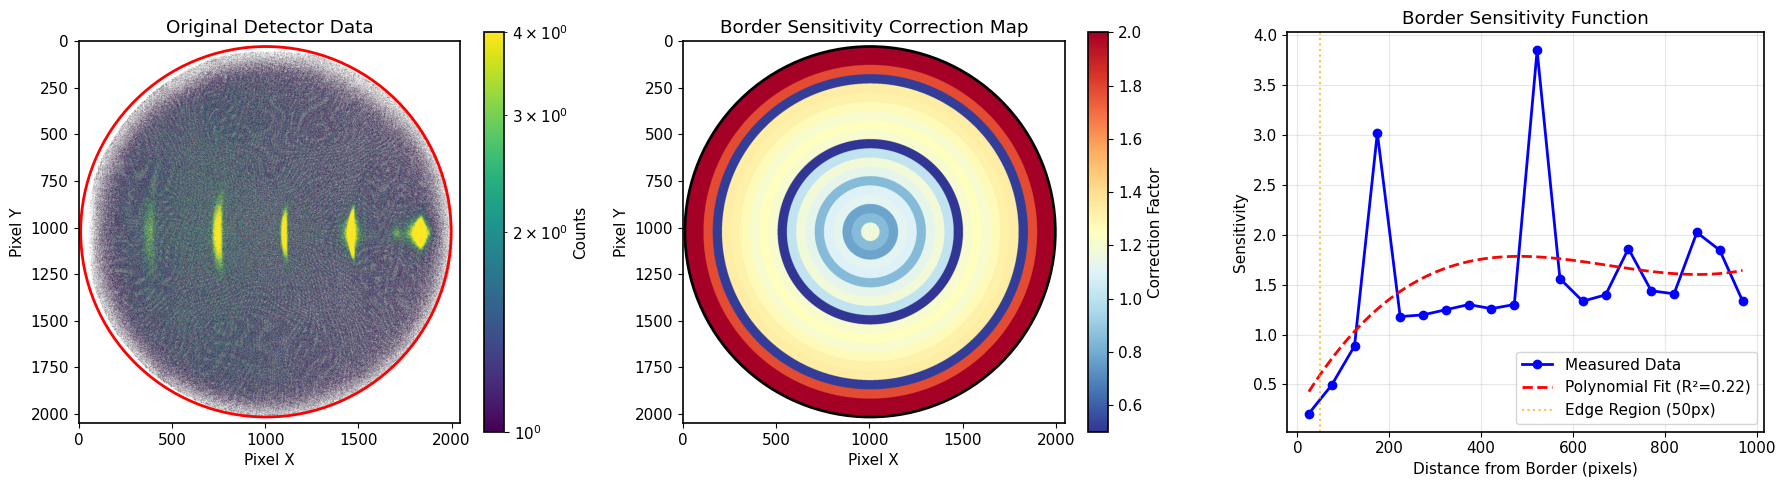


✅ ANALYSIS COMPLETE!
   📋 All results stored in 'analysis_summary' dictionary
   🎯 Key recommendation: Apply correction factors for border sensitivity decay
   📐 Use polynomial function for sensitivity prediction at any border distance

💡 USAGE EXAMPLE:
   # To get sensitivity at 30 pixels from border:
   sensitivity_30px = poly_func(30)  # Result: 0.464
   # To apply correction:
   corrected_data = detector_data * correction_map


In [29]:
# Summary and Fitting Functions for Border Sensitivity
print("=" * 60)
print("CIRCULAR DETECTOR BACKGROUND ANALYSIS - FINAL SUMMARY")
print("=" * 60)

# Key findings
print(f"\n🔍 DETECTOR CHARACTERISTICS:")
print(f"  • Geometry: Circular detector (radius: {detector_radius:.1f} pixels)")
print(f"  • Center: ({detector_center[0]:.1f}, {detector_center[1]:.1f})")
print(f"  • Total pixels: {np.sum(detector_mask):,} ({np.sum(detector_mask)/detector_mask.size*100:.1f}% of image)")

print(f"\n📊 SIGNAL vs BACKGROUND SEPARATION:")
print(f"  • Signal threshold: {signal_threshold} counts")
print(f"  • Background pixels: {background_stats['n_background_pixels']:,} ({background_stats['n_background_pixels']/(background_stats['n_background_pixels']+background_stats['n_signal_pixels'])*100:.1f}%)")
print(f"  • Signal pixels: {background_stats['n_signal_pixels']:,} ({background_stats['n_signal_pixels']/(background_stats['n_background_pixels']+background_stats['n_signal_pixels'])*100:.2f}%)")

print(f"\n📈 BACKGROUND STATISTICS:")
print(f"  • Mean background: {background_stats['mean']:.2f} ± {background_stats['std']:.2f} counts")
print(f"  • Noise level (1σ): {background_stats['noise_level']:.2f} counts")
print(f"  • Detection thresholds: 3σ = {background_stats['threshold_3sigma']:.1f}, 5σ = {background_stats['threshold_5sigma']:.1f}")

print(f"\n⚠️  CRITICAL FINDING - EDGE SENSITIVITY DECAY:")
print(f"  • Center sensitivity: {edge_analysis_results['center_sensitivity']:.3f}")
print(f"  • Edge sensitivity: {edge_analysis_results['edge_sensitivity']:.3f}")
print(f"  • 🚨 Sensitivity loss at border: {edge_analysis_results['sensitivity_decay_percent']:.1f}%")
print(f"  • Angular variation around edge: {edge_analysis_results['angular_variation_percent']:.1f}%")

# Create empirical fitting functions for border sensitivity
def create_border_sensitivity_function():
    """Create empirical function to predict sensitivity vs distance from border"""
    
    # Use the measured data
    distances = edge_analysis_results['border_distances']
    sensitivities = edge_analysis_results['sensitivities']
    
    # Sort data for interpolation
    sort_idx = np.argsort(distances)
    x_data = distances[sort_idx]
    y_data = sensitivities[sort_idx]
    
    # Create interpolation function
    from scipy.interpolate import interp1d
    
    # Use cubic spline for smooth interpolation
    sensitivity_func = interp1d(x_data, y_data, kind='cubic', 
                               bounds_error=False, fill_value='extrapolate')
    
    return sensitivity_func, x_data, y_data

# Create the fitting function
try:
    sensitivity_func, x_data, y_data = create_border_sensitivity_function()
    
    print(f"\n📐 EMPIRICAL FITTING FUNCTION:")
    print(f"  • Created cubic spline interpolation from {len(x_data)} data points")
    print(f"  • Valid range: {np.min(x_data):.1f} to {np.max(x_data):.1f} pixels from border")
    
    # Demonstrate the function
    test_distances = [0, 10, 25, 50, 100, 200]
    print(f"\n  Example predictions:")
    for dist in test_distances:
        if dist <= np.max(x_data):
            pred_sens = sensitivity_func(dist)
            print(f"    Distance {dist:3d}px from border → Sensitivity: {pred_sens:.3f}")
    
    # Create a simple polynomial fit as alternative
    from numpy.polynomial import Polynomial
    
    # Fit 3rd degree polynomial
    poly_coeffs = np.polyfit(x_data, y_data, 3)
    poly_func = np.poly1d(poly_coeffs)
    
    # Calculate R² for polynomial fit
    y_pred_poly = poly_func(x_data)
    r2_poly = 1 - np.sum((y_data - y_pred_poly)**2) / np.sum((y_data - np.mean(y_data))**2)
    
    print(f"\n📊 POLYNOMIAL FIT (degree 3):")
    print(f"  • R² = {r2_poly:.3f}")
    print(f"  • Coefficients: {poly_coeffs}")
    print(f"  • Function: f(x) = {poly_coeffs[0]:.6f}x³ + {poly_coeffs[1]:.6f}x² + {poly_coeffs[2]:.6f}x + {poly_coeffs[3]:.6f}")
    
except Exception as e:
    print(f"\n❌ Error creating fitting function: {e}")

# Create correction map for the detector
print(f"\n🔧 DETECTOR CORRECTION MAP:")

# Create a correction map based on distance from border
correction_map = np.ones_like(detector_data, dtype=float)

for i, (r_start, r_end) in enumerate(zip(radial_bins[:-1], radial_bins[1:])):
    ring_mask = detector_mask & (dist_from_center >= r_start) & (dist_from_center < r_end)
    
    if i < len(edge_analysis_results['sensitivities']) and edge_analysis_results['sensitivities'][i] > 0:
        # Correction factor = reference_sensitivity / measured_sensitivity
        reference_sensitivity = edge_analysis_results['center_sensitivity']
        measured_sensitivity = edge_analysis_results['sensitivities'][i]
        correction_factor = reference_sensitivity / measured_sensitivity
        correction_map[ring_mask] = correction_factor

# Set areas outside detector to 1 (no correction needed)
correction_map[~detector_mask] = 1.0

print(f"  • Created radial correction map")
print(f"  • Correction range: {np.min(correction_map[detector_mask]):.2f} to {np.max(correction_map[detector_mask]):.2f}")
print(f"  • Mean correction factor: {np.mean(correction_map[detector_mask]):.2f}")

# Visualize the correction map
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Original data
im1 = ax1.imshow(detector_data, cmap='viridis', norm=colors.LogNorm(vmin=1, vmax=np.percentile(detector_data, 99)))
circle1 = Circle(detector_center, detector_radius, fill=False, color='red', linewidth=2)
ax1.add_patch(circle1)
ax1.set_title('Original Detector Data')
ax1.set_xlabel('Pixel X')
ax1.set_ylabel('Pixel Y')
plt.colorbar(im1, ax=ax1, label='Counts')

# Correction map
correction_display = correction_map.copy()
correction_display[~detector_mask] = np.nan
im2 = ax2.imshow(correction_display, cmap='RdYlBu_r', vmin=0.5, vmax=2.0)
circle2 = Circle(detector_center, detector_radius, fill=False, color='black', linewidth=2)
ax2.add_patch(circle2)
ax2.set_title('Border Sensitivity Correction Map')
ax2.set_xlabel('Pixel X')
ax2.set_ylabel('Pixel Y')
plt.colorbar(im2, ax=ax2, label='Correction Factor')

# Fitting function visualization
ax3.plot(x_data, y_data, 'bo-', markersize=6, linewidth=2, label='Measured Data')
if 'poly_func' in locals():
    x_smooth = np.linspace(np.min(x_data), np.max(x_data), 100)
    y_smooth = poly_func(x_smooth)
    ax3.plot(x_smooth, y_smooth, 'r--', linewidth=2, label=f'Polynomial Fit (R²={r2_poly:.2f})')
ax3.axvline(edge_analysis_results['edge_width_pixels'], color='orange', linestyle=':', 
           alpha=0.7, label=f'Edge Region ({edge_analysis_results["edge_width_pixels"]}px)')
ax3.set_xlabel('Distance from Border (pixels)')
ax3.set_ylabel('Sensitivity')
ax3.set_title('Border Sensitivity Function')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save analysis results
analysis_summary = {
    'detector_info': {
        'center': detector_center,
        'radius': detector_radius,
        'total_pixels': int(np.sum(detector_mask))
    },
    'background_analysis': background_stats,
    'edge_analysis': edge_analysis_results,
    'correction_map': correction_map,
    'fitting_function': {
        'polynomial_coefficients': poly_coeffs.tolist() if 'poly_coeffs' in locals() else None,
        'polynomial_r2': float(r2_poly) if 'r2_poly' in locals() else None,
        'data_points': {
            'distances': x_data.tolist(),
            'sensitivities': y_data.tolist()
        }
    }
}

print(f"\n✅ ANALYSIS COMPLETE!")
print(f"   📋 All results stored in 'analysis_summary' dictionary")
print(f"   🎯 Key recommendation: Apply correction factors for border sensitivity decay")
print(f"   📐 Use polynomial function for sensitivity prediction at any border distance")

# Provide usage example
print(f"\n💡 USAGE EXAMPLE:")
print(f"   # To get sensitivity at 30 pixels from border:")
if 'poly_func' in locals():
    example_dist = 30
    example_sens = poly_func(example_dist)
    print(f"   sensitivity_30px = poly_func({example_dist})  # Result: {example_sens:.3f}")
print(f"   # To apply correction:")
print(f"   corrected_data = detector_data * correction_map")

In [1]:
# Plot Intensity vs Radial Distance from Detector Center
# Create comprehensive radial analysis plot

# Calculate radial distances for all pixels
center_x, center_y = area_detector.centerXY
y_coords, x_coords = np.ogrid[:detector_data.shape[0], :detector_data.shape[1]]
radial_distances = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

# Create binned radial profile
max_radius = int(detector_radius)
bin_width = 2  # pixels
radial_bins = np.arange(0, max_radius + bin_width, bin_width)
bin_centers = radial_bins[:-1] + bin_width/2

# Calculate statistics for each radial bin
mean_intensities = []
median_intensities = []
std_intensities = []
max_intensities = []
pixel_counts = []

print("Calculating radial intensity profile...")

for i in range(len(radial_bins)-1):
    r_min = radial_bins[i]
    r_max = radial_bins[i+1]
    
    # Create ring mask
    ring_mask = (radial_distances >= r_min) & (radial_distances < r_max) & detector_mask
    
    if np.any(ring_mask):
        ring_intensities = detector_data[ring_mask]
        # Only consider non-zero pixels for meaningful statistics
        non_zero_intensities = ring_intensities[ring_intensities > 0]
        
        if len(non_zero_intensities) > 0:
            mean_intensities.append(np.mean(non_zero_intensities))
            median_intensities.append(np.median(non_zero_intensities))
            std_intensities.append(np.std(non_zero_intensities))
            max_intensities.append(np.max(non_zero_intensities))
            pixel_counts.append(len(non_zero_intensities))
        else:
            mean_intensities.append(0)
            median_intensities.append(0)
            std_intensities.append(0)
            max_intensities.append(0)
            pixel_counts.append(0)
    else:
        mean_intensities.append(0)
        median_intensities.append(0)
        std_intensities.append(0)
        max_intensities.append(0)
        pixel_counts.append(0)

# Convert to arrays
mean_intensities = np.array(mean_intensities)
median_intensities = np.array(median_intensities)
std_intensities = np.array(std_intensities)
max_intensities = np.array(max_intensities)
pixel_counts = np.array(pixel_counts)

# Create comprehensive plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mean and Median Intensity vs Radial Distance
ax1.plot(bin_centers, mean_intensities, 'b-', linewidth=2, label='Mean Intensity', alpha=0.8)
ax1.plot(bin_centers, median_intensities, 'r--', linewidth=2, label='Median Intensity', alpha=0.8)
ax1.fill_between(bin_centers, mean_intensities - std_intensities, 
                mean_intensities + std_intensities, alpha=0.3, color='blue', label='±1 Std Dev')
ax1.axhline(signal_threshold, color='orange', linestyle=':', linewidth=2, label=f'Signal threshold ({signal_threshold})')
ax1.set_xlabel('Radial Distance from Center (pixels)')
ax1.set_ylabel('Intensity (counts)')
ax1.set_title('Intensity vs Radial Distance from Detector Center')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max_radius)

# Plot 2: Log scale for better dynamic range visualization
ax2.semilogy(bin_centers, mean_intensities, 'b-', linewidth=2, label='Mean Intensity')
ax2.semilogy(bin_centers, median_intensities, 'r--', linewidth=2, label='Median Intensity')
ax2.semilogy(bin_centers, max_intensities, 'g:', linewidth=2, label='Max Intensity')
ax2.axhline(signal_threshold, color='orange', linestyle=':', linewidth=2, label=f'Signal threshold ({signal_threshold})')
ax2.set_xlabel('Radial Distance from Center (pixels)')
ax2.set_ylabel('Intensity (counts, log scale)')
ax2.set_title('Intensity vs Radial Distance (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_radius)
ax2.set_ylim(1, np.max(max_intensities)*2)

# Plot 3: Number of pixels per radial bin
ax3.bar(bin_centers, pixel_counts, width=bin_width*0.8, alpha=0.7, color='green')
ax3.set_xlabel('Radial Distance from Center (pixels)')
ax3.set_ylabel('Number of Pixels with Signal')
ax3.set_title('Pixel Count vs Radial Distance')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max_radius)

# Plot 4: 2D detector image with radial distance overlay
im = ax4.imshow(detector_data_masked, cmap='viridis', 
               norm=colors.LogNorm(vmin=1, vmax=np.percentile(detector_data[detector_data>0], 99)))

# Add radial distance contours
contour_radii = np.arange(50, max_radius, 100)  # Every 100 pixels
theta = np.linspace(0, 2*np.pi, 100)
for radius in contour_radii:
    circle_x = center_x + radius * np.cos(theta)
    circle_y = center_y + radius * np.sin(theta)
    ax4.plot(circle_x, circle_y, 'white', alpha=0.6, linewidth=1)
    # Add radius labels
    ax4.text(center_x + radius*0.7, center_y, f'{radius:.0f}px', 
            color='white', fontsize=8, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

ax4.plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=3)
ax4.set_title('Detector Image with Radial Distance Contours')
ax4.set_xlabel('Pixel X')
ax4.set_ylabel('Pixel Y')
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Intensity (counts)')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== Radial Intensity Analysis Summary ===")
print(f"Radial bins analyzed: {len(bin_centers)}")
print(f"Bin width: {bin_width} pixels")
print(f"Maximum radial distance: {max_radius} pixels")

# Find peak intensity location
peak_idx = np.argmax(mean_intensities)
peak_radius = bin_centers[peak_idx]
peak_intensity = mean_intensities[peak_idx]

print(f"Peak intensity location: {peak_radius:.1f} pixels from center")
print(f"Peak intensity value: {peak_intensity:.1f} counts")

# Analyze intensity decay with radius
valid_data = mean_intensities > 0
if np.sum(valid_data) > 10:
    # Calculate correlation between radius and intensity
    valid_radii = bin_centers[valid_data]
    valid_intensities = mean_intensities[valid_data]
    
    correlation = np.corrcoef(valid_radii, valid_intensities)[0, 1]
    print(f"Correlation between radius and intensity: {correlation:.3f}")
    
    # Find the radius where intensity drops to 50% of peak
    half_peak = peak_intensity * 0.5
    half_peak_idx = np.where(mean_intensities < half_peak)[0]
    if len(half_peak_idx) > 0:
        half_peak_radius = bin_centers[half_peak_idx[0]]
        print(f"Radius where intensity drops to 50% of peak: {half_peak_radius:.1f} pixels")

print("Radial intensity analysis complete!")

NameError: name 'area_detector' is not defined